# 🌡️ Heatwave Dynamics Analysis – Bucharest, Romania (1961–2025)
**Methodology:** Climpact Tx90 Heatwave Indices (HWN, HWF, HWD, HWM, HWA)  
**Baseline period:** 1971–2000 | **Heatwave definition:** ≥3 consecutive days with TX > 90th percentile  
**Data:** ANM NetCDF daily maximum temperature grids  
**Output folder:** `My Drive/Workshop_DeltaHUB/00_Proiectul_meu/`

## 📦 BLOCK 1 — Install dependencies & mount Google Drive

In [ ]:
# ── Install all required libraries ──────────────────────────────────────────
!pip install -q xarray netCDF4 zarr geopandas rioxarray scipy pymannkendall \
              statsmodels folium matplotlib cartopy dask pyproj shapely \
              xesmf regionmask fsspec aiofiles plotly

# ── Mount Google Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('✅ Google Drive mounted.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.0 MB/s eta 0:00:00
Mounted at /content/drive
✅ Google Drive mounted.


## 📁 BLOCK 2 — Define paths & global settings

In [ ]:
import os

# ── Root paths ───────────────────────────────────────────────────────────────
DRIVE_ROOT   = '/content/drive/MyDrive'
NC_DATA_DIR  = os.path.join(DRIVE_ROOT, 'ANM_Datasets', '01_Temperatura_maxima')
OUTPUT_DIR   = os.path.join(DRIVE_ROOT, 'Workshop_DeltaHUB', '00_Proiectul_meu')
AOI_DIR      = os.path.join(OUTPUT_DIR, '00_Baza_date', '01_AOI')

# ── Sub-output folders (created automatically) ──────────────────────────────
MERGED_DIR   = os.path.join(OUTPUT_DIR, '01_Date_prelucrate')
ZARR_DIR     = os.path.join(OUTPUT_DIR, '02_Zarr_files')
INDICES_DIR  = os.path.join(OUTPUT_DIR, '03_Heatwave_Indices')
STATS_DIR    = os.path.join(OUTPUT_DIR, '04_Statistics')
MAPS_DIR     = os.path.join(OUTPUT_DIR, '05_Maps')

for d in [MERGED_DIR, ZARR_DIR, INDICES_DIR, STATS_DIR, MAPS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Analysis settings ────────────────────────────────────────────────────────
BASELINE_START = 1971
BASELINE_END   = 2000
HW_PERCENTILE  = 90        # Tx90p
HW_MIN_DAYS    = 3         # consecutive days threshold
HEATWAVE_SEASON = [5,6,7,8,9]   # May–Sep (Northern Hemisphere)
TARGET_YEARS   = range(1961, 2026)
REGRID_YEARS   = [2023, 2024, 2025]   # years that may need regridding

print('✅ Paths and settings configured.')
print(f'   NC data : {NC_DATA_DIR}')
print(f'   Output  : {OUTPUT_DIR}')

✅ Paths and settings configured.
   NC data : /content/drive/MyDrive/ANM_Datasets/01_Temperatura_maxima
   Output  : /content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu


## 📂 BLOCK 3 — List & inspect NetCDF files, detect resolution changes

In [ ]:
import glob
import xarray as xr
import numpy as np
import pandas as pd

# ── Find all .nc files ────────────────────────────────────────────────────────
nc_files = sorted(glob.glob(os.path.join(NC_DATA_DIR, '**', '*.nc'), recursive=True))
if not nc_files:
    nc_files = sorted(glob.glob(os.path.join(NC_DATA_DIR, '*.nc')))

print(f'Found {len(nc_files)} NetCDF file(s).')

# ── Inspect each file: time range, shape, resolution ─────────────────────────
meta = []
for f in nc_files:
    try:
        ds = xr.open_dataset(f, decode_times=True)
        # Detect coordinate names (lat/lon or y/x)
        lat_name = [v for v in ds.coords if v.lower() in ['lat','latitude','y']][0]
        lon_name = [v for v in ds.coords if v.lower() in ['lon','longitude','x']][0]
        lat_res = float(np.abs(np.diff(ds[lat_name].values).mean()).round(4))
        lon_res = float(np.abs(np.diff(ds[lon_name].values).mean()).round(4))
        time_range = f"{str(ds.time.values[0])[:10]} → {str(ds.time.values[-1])[:10]}"
        meta.append({'file': os.path.basename(f), 'lat_res': lat_res,
                     'lon_res': lon_res, 'shape': dict(ds.dims), 'time': time_range})
        ds.close()
    except Exception as e:
        meta.append({'file': os.path.basename(f), 'error': str(e)})

df_meta = pd.DataFrame(meta)
print('\n📋 File inventory:')
print(df_meta.to_string(index=False))

# ── Flag years that differ in resolution (likely need regridding) ─────────────
if 'lat_res' in df_meta.columns:
    ref_res = df_meta['lat_res'].mode()[0]
    needs_regrid = df_meta[df_meta['lat_res'] != ref_res]['file'].tolist()
    print(f'\n⚠️  Reference resolution: {ref_res}°')
    print(f'   Files needing regridding: {needs_regrid if needs_regrid else "None"}')
    print(f'   (You mentioned 2023/2024/2025 may need regridding — verify above.)')

Found 65 NetCDF file(s).


/tmp/ipykernel_1048/2756163094.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'lon_res': lon_res, 'shape': dict(ds.dims), 'time': time_range})



📋 File inventory:
                    file  lat_res  lon_res                                 shape                    time                                                                                                                         error
daily_tmax_synop_1961.nc     0.01     0.01 {'time': 365, 'lat': 483, 'lon': 972} 1961-01-01 → 1961-12-31                                                                                                                           NaN
daily_tmax_synop_1962.nc      NaN      NaN                                   NaN                     NaN [Errno -51] NetCDF: Unknown file format: '/content/drive/MyDrive/ANM_Datasets/01_Temperatura_maxima/daily_tmax_synop_1962.nc'
daily_tmax_synop_1963.nc      NaN      NaN                                   NaN                     NaN                            No such file: '/content/drive/MyDrive/ANM_Datasets/01_Temperatura_maxima/daily_tmax_synop_1963.nc'
daily_tmax_synop_1964.nc      NaN      NaN               

/usr/local/lib/python3.12/dist-packages/xarray/backends/api.py:588: RuntimeWarning: 'netcdf4' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
/usr/local/lib/python3.12/dist-packages/xarray/backends/api.py:588: RuntimeWarning: 'h5netcdf' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
/usr/local/lib/python3.12/dist-packages/xarray/backends/api.py:588: RuntimeWarning: 'scipy' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


## 🗺️ BLOCK 4 — Load & prepare the AOI Shapefile

Reading package lists...
Building dependency tree...
Reading state information...
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
📦 Found archive: /content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/00_Baza_date/01_AOI/00_AOI.rar
📂 Extracted to: /content/aoi_shapefile
✅ AOI loaded: /content/aoi_shapefile/00_AOI/00_AOI.shp
   CRS: EPSG:4326  |  Features: 1
   Bounding box: [25.60074294 44.07612787 26.58048932 44.80402403]


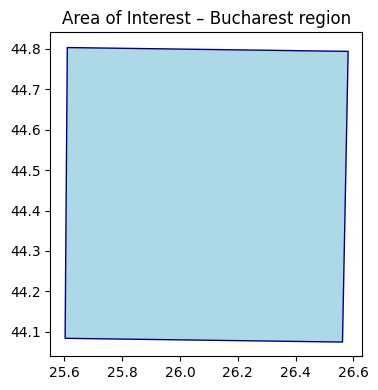

In [ ]:
# ── BLOCK 4 (RAR version) — Install unrar, extract AOI, load shapefile ────────
import glob, os
import geopandas as gpd

# Install unrar
!apt-get install -q unrar

AOI_EXTRACT = '/content/aoi_shapefile'
os.makedirs(AOI_EXTRACT, exist_ok=True)

# Find the .rar file
rar_files = glob.glob(os.path.join(AOI_DIR, '**', '*.rar'), recursive=True)
assert rar_files, f'No .rar file found in {AOI_DIR}'
aoi_rar = rar_files[0]
print(f'📦 Found archive: {aoi_rar}')

# Extract
os.system(f'unrar x -o+ "{aoi_rar}" "{AOI_EXTRACT}/"')
print(f'📂 Extracted to: {AOI_EXTRACT}')

# Find .shp
shp_files = glob.glob(os.path.join(AOI_EXTRACT, '**', '*.shp'), recursive=True)
assert shp_files, f'No .shp found after extraction. Check: {AOI_EXTRACT}'

# Load
aoi = gpd.read_file(shp_files[0]).to_crs('EPSG:4326')
print(f'✅ AOI loaded: {shp_files[0]}')
print(f'   CRS: {aoi.crs}  |  Features: {len(aoi)}')
print(f'   Bounding box: {aoi.total_bounds}')

import matplotlib.pyplot as plt
aoi.plot(figsize=(5,4), color='lightblue', edgecolor='navy')
plt.title('Area of Interest – Bucharest region')
plt.tight_layout(); plt.show()

## ✂️ BLOCK 5 — Clip / mask NetCDF files to AOI (only valid pixels)

In [ ]:
import rioxarray  # adds .rio accessor to xarray
from shapely.geometry import mapping

def detect_names(ds):
    """Detect lat/lon coordinate names and main temperature variable."""
    lat_name = [v for v in ds.coords if v.lower() in ['lat','latitude','y']][0]
    lon_name = [v for v in ds.coords if v.lower() in ['lon','longitude','x']][0]
    var_name  = [v for v in ds.data_vars][0]   # assume single variable
    return lat_name, lon_name, var_name

def clip_to_aoi(ds, lat_name, lon_name, aoi_gdf):
    """Assign spatial reference and clip dataset to AOI polygon."""
    ds = ds.rename({lat_name: 'y', lon_name: 'x'})
    ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
    ds = ds.rio.write_crs('EPSG:4326')
    ds_clipped = ds.rio.clip(aoi_gdf.geometry.apply(mapping),
                             aoi_gdf.crs, drop=True, all_touched=True)
    # Restore original coordinate names for consistency
    ds_clipped = ds_clipped.rename({'y': lat_name, 'x': lon_name})
    return ds_clipped

# ── Clip all files and store results ──────────────────────────────────────────
clipped_datasets = []

for f in nc_files:
    ds = xr.open_dataset(f, decode_times=True, chunks={'time': 365})
    lat_name, lon_name, var_name = detect_names(ds)
    ds_clip = clip_to_aoi(ds, lat_name, lon_name, aoi)
    clipped_datasets.append({'ds': ds_clip, 'lat': lat_name, 'lon': lon_name,
                              'var': var_name, 'file': os.path.basename(f)})
    print(f'  ✅ Clipped {os.path.basename(f)} → shape {dict(ds_clip.dims)}')

print(f'\n✅ All {len(clipped_datasets)} files clipped to AOI.')

/tmp/ipykernel_1048/2607113692.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'  ✅ Clipped {os.path.basename(f)} → shape {dict(ds_clip.dims)}')


  ✅ Clipped daily_tmax_synop_1961.nc → shape {'lon': 99, 'lat': 74, 'time': 365}


/tmp/ipykernel_1048/2607113692.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'  ✅ Clipped {os.path.basename(f)} → shape {dict(ds_clip.dims)}')


  ✅ Clipped daily_tmax_synop_1962.nc → shape {'lon': 99, 'lat': 74, 'time': 365}


/tmp/ipykernel_1048/2607113692.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'  ✅ Clipped {os.path.basename(f)} → shape {dict(ds_clip.dims)}')


...

/tmp/ipykernel_1048/2607113692.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'  ✅ Clipped {os.path.basename(f)} → shape {dict(ds_clip.dims)}')


  ✅ Clipped daily_tmax_synop_2023.nc → shape {'lon': 99, 'lat': 74, 'time': 365}


/tmp/ipykernel_1048/2607113692.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'  ✅ Clipped {os.path.basename(f)} → shape {dict(ds_clip.dims)}')


  ✅ Clipped daily_tmax_synop_2024.nc → shape {'lon': 99, 'lat': 74, 'time': 366}
  ✅ Clipped daily_tmax_synop_2025.nc → shape {'lon': 99, 'lat': 74, 'time': 365}

✅ All 65 files clipped to AOI.


/tmp/ipykernel_1048/2607113692.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'  ✅ Clipped {os.path.basename(f)} → shape {dict(ds_clip.dims)}')


## 🔄 BLOCK 6 — Regrid recent files (2023/2024/2025) to common grid if needed

In [ ]:
# ── BLOCK 6 (FIXED — no xesmf) — Regrid with xarray interp if needed ─────────
from scipy.interpolate import RegularGridInterpolator

def regrid_to_reference(ds, lat_n, lon_n, ref_lats, ref_lons):
    """Bilinear regrid a dataset to reference lat/lon grid using xarray.interp."""
    return ds.interp(
        {lat_n: ref_lats, lon_n: ref_lons},
        method='linear',
        kwargs={'fill_value': None}   # extrapolate at edges
    )

# Reference grid from first dataset
ref_item = clipped_datasets[0]
ref_lats = ref_item['ds'][ref_item['lat']].values
ref_lons = ref_item['ds'][ref_item['lon']].values

print(f'📐 Reference grid: {len(ref_lats)} lats × {len(ref_lons)} lons')

regridded_list = []

for item in clipped_datasets:
    ds    = item['ds']
    lat_n = item['lat']
    lon_n = item['lon']

    cur_lats = ds[lat_n].values
    cur_lons = ds[lon_n].values

    same = (len(cur_lats) == len(ref_lats) and
            len(cur_lons) == len(ref_lons) and
            np.allclose(cur_lats, ref_lats, rtol=1e-3) and
            np.allclose(cur_lons, ref_lons, rtol=1e-3))

    if same:
        print(f'  ✅ {item["file"]} — grid matches, no regridding.')
        regridded_list.append(ds)
    else:
        print(f'  🔄 {item["file"]} — regridding {cur_lats.shape}→{ref_lats.shape}...')
        ds_out = regrid_to_reference(ds, lat_n, lon_n, ref_lats, ref_lons)
        regridded_list.append(ds_out)
        print(f'     → Done: {dict(ds_out.dims)}')

print('\n✅ Regridding complete (xarray.interp bilinear).')

📐 Reference grid: 74 lats × 99 lons
  ✅ daily_tmax_synop_1961.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1962.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1963.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1964.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1965.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1966.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1967.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1968.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1969.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1970.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1971.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1972.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1973.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1974.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1975.nc — grid matches, no regridding.
  ✅ daily_tmax_synop_1976.nc — grid matches, no regridding.
  ✅ 

## 🔗 BLOCK 7 — Merge all years into a single NetCDF (1961–2025)

In [ ]:
# ── Get variable name from first dataset ─────────────────────────────────────
var_name = list(regridded_list[0].data_vars)[0]

# ── Concatenate along time ────────────────────────────────────────────────────
print('🔗 Merging all datasets along time dimension...')
ds_merged = xr.concat(regridded_list, dim='time', data_vars='all')
ds_merged = ds_merged.sortby('time')   # ensure chronological order

# ── Add metadata ─────────────────────────────────────────────────────────────
ds_merged[var_name].attrs.update({
    'long_name'   : 'Daily maximum temperature',
    'standard_name': 'air_temperature',
    'units'       : ds_merged[var_name].attrs.get('units', '°C'),
    'source'      : 'ANM – Administratia Nationala de Meteorologie',
    'AOI'         : 'Bucharest region, Romania'
})
ds_merged.attrs = {
    'title'      : 'Daily Maximum Temperature – Bucharest Region 1961-2025',
    'institution': 'ANM Romania',
    'created_by' : 'Heatwave Analysis Notebook'
}

print(f'   Time range : {str(ds_merged.time.values[0])[:10]} → {str(ds_merged.time.values[-1])[:10]}')
print(f'   Shape      : {dict(ds_merged.dims)}')

# ── Save merged NetCDF ────────────────────────────────────────────────────────
merged_nc_path = os.path.join(MERGED_DIR, 'TX_Bucharest_1961_2025_merged.nc')
ds_merged.to_netcdf(merged_nc_path, mode='w',
                    encoding={var_name: {'zlib': True, 'complevel': 5}})
print(f'\n✅ Merged NetCDF saved: {merged_nc_path}')

🔗 Merging all datasets along time dimension...


/tmp/ipykernel_1048/2398007196.py:6: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lon' ('lon',) The recommendation is to set join explicitly for this case.
  ds_merged = xr.concat(regridded_list, dim='time', data_vars='all')
/tmp/ipykernel_1048/2398007196.py:6: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  ds_merged = xr.concat(regridded_list, dim='time', data_vars='all')


   Time range : 1961-01-01 → 2025-12-31
   Shape      : {'time': 23741, 'lat': 148, 'lon': 198}


/tmp/ipykernel_1048/2398007196.py:24: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'   Shape      : {dict(ds_merged.dims)}')



✅ Merged NetCDF saved: /content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/01_Date_prelucrate/TX_Bucharest_1961_2025_merged.nc


## 💾 BLOCK 8 — Convert merged NetCDF → Zarr

In [ ]:
import zarr

zarr_merged_path = os.path.join(ZARR_DIR, 'TX_Bucharest_1961_2025_merged.zarr')

print('💾 Converting merged NetCDF to Zarr...')
# Rechunk for efficient time-series access
ds_zarr = ds_merged.chunk({'time': 365, 'lat': 50, 'lon': 50})
ds_zarr.to_zarr(zarr_merged_path, mode='w', consolidated=True)

print(f'✅ Zarr store saved: {zarr_merged_path}')

# Verification
ds_check = xr.open_zarr(zarr_merged_path, consolidated=True)
print(f'   Verified. Dimensions: {dict(ds_check.dims)}')

💾 Converting merged NetCDF to Zarr...


/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


✅ Zarr store saved: /content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/02_Zarr_files/TX_Bucharest_1961_2025_merged.zarr
   Verified. Dimensions: {'time': 23741, 'lat': 148, 'lon': 198}


/tmp/ipykernel_1048/2709504909.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'   Verified. Dimensions: {dict(ds_check.dims)}')


## 🌡️ BLOCK 9 — Compute Tx90p baseline percentile (1971–2000, day-of-year)

In [ ]:
# ── Load from Zarr ────────────────────────────────────────────────────────────
ds_all = xr.open_zarr(zarr_merged_path, consolidated=True)
var_name = list(ds_all.data_vars)[0]
TX = ds_all[var_name]

# ── Filter baseline period ────────────────────────────────────────────────────
TX_base = TX.sel(time=TX.time.dt.year.isin(range(BASELINE_START, BASELINE_END+1)))
print(f'Baseline years: {BASELINE_START}–{BASELINE_END}  |  '
      f'Days: {len(TX_base.time)}')

# ── Climpact approach: bootstrap-adjusted 90th percentile by day-of-year ─────
# For each of the 365 DOYs, compute 90th pctile using a 15-day window
# around that DOY across all baseline years (standard method)
WINDOW = 15   # ±7 days each side (15-day window centered on DOY)

doys = np.arange(1, 366)
# Collect all lat/lon coords
lats = TX_base.lat.values if 'lat' in TX_base.coords else TX_base.y.values
lons = TX_base.lon.values if 'lon' in TX_base.coords else TX_base.x.values

lat_name = 'lat' if 'lat' in TX_base.coords else 'y'
lon_name = 'lon' if 'lon' in TX_base.coords else 'x'

# Precompute DOY array
TX_base_doy = TX_base.time.dt.dayofyear.values

# Build a (365, nlat, nlon) percentile array
nlat = len(lats)
nlon = len(lons)
tx90p = np.full((365, nlat, nlon), np.nan, dtype=np.float32)

# Load baseline data into memory once
TX_base_vals = TX_base.values  # (time, lat, lon)

for doy in doys:
    # Build window: ±7 days, wrapping around year
    win_doys = [(doy - 7 + d) % 365 + 1 for d in range(WINDOW)]
    idx = np.isin(TX_base_doy, win_doys)
    subset = TX_base_vals[idx]   # (n_days_in_window * n_years, lat, lon)
    if subset.size > 0:
        tx90p[doy-1] = np.nanpercentile(subset, HW_PERCENTILE, axis=0)

# Wrap into DataArray
tx90p_da = xr.DataArray(
    tx90p,
    dims=['dayofyear', lat_name, lon_name],
    coords={'dayofyear': doys, lat_name: lats, lon_name: lons},
    name='tx90p'
)
print(f'✅ Tx90p computed for 365 DOYs. Shape: {tx90p_da.shape}')

# ── Save threshold ────────────────────────────────────────────────────────────
tx90p_da.to_netcdf(os.path.join(INDICES_DIR, 'tx90p_threshold_1971_2000.nc'))
print('✅ Threshold saved.')

Baseline years: 1971–2000  |  Days: 10958


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


✅ Tx90p computed for 365 DOYs. Shape: (365, 148, 198)
✅ Threshold saved.


## 🔥 BLOCK 10 — Identify heatwave days & compute 5 Climpact indices (per year, per pixel)

In [ ]:
# ── Full restore after kernel restart ────────────────────────────────────────
import xarray as xr, numpy as np, os, glob

DRIVE_ROOT  = '/content/drive/MyDrive'
OUTPUT_DIR  = os.path.join(DRIVE_ROOT, 'Workshop_DeltaHUB', '00_Proiectul_meu')
ZARR_DIR    = os.path.join(OUTPUT_DIR, '02_Zarr_files')
INDICES_DIR = os.path.join(OUTPUT_DIR, '03_Heatwave_Indices')

BASELINE_START  = 1971
BASELINE_END    = 2000
HW_PERCENTILE   = 90
HW_MIN_DAYS     = 3
HEATWAVE_SEASON = [5,6,7,8,9]

zarr_merged_path = os.path.join(ZARR_DIR, 'TX_Bucharest_1961_2025_merged.zarr')
ds_all   = xr.open_zarr(zarr_merged_path, consolidated=True)
var_name = list(ds_all.data_vars)[0]
TX       = ds_all[var_name]

lat_name = 'lat' if 'lat' in TX.coords else 'y'
lon_name = 'lon' if 'lon' in TX.coords else 'x'
lats     = TX[lat_name].values
lons     = TX[lon_name].values

tx90p_da = xr.open_dataarray(os.path.join(INDICES_DIR, 'tx90p_threshold_1971_2000.nc'))
tx90p    = tx90p_da.values   # (365, nlat, nlon)

TX_vals  = TX.values
TX_time  = TX.time.values
TX_year  = TX.time.dt.year.values
TX_month = TX.time.dt.month.values
TX_doy   = TX.time.dt.dayofyear.values

print(f'✅ Restored. TX shape: {TX.shape}, tx90p shape: {tx90p.shape}')

✅ Restored. TX shape: (23741, 148, 198), tx90p shape: (365, 148, 198)


In [ ]:
# ── Reload if kernel was restarted ───────────────────────────────────────────
import xarray as xr, numpy as np, os

zarr_merged_path = os.path.join(ZARR_DIR, 'TX_Bucharest_1961_2025_merged.zarr')
ds_all   = xr.open_zarr(zarr_merged_path, consolidated=True)
var_name = list(ds_all.data_vars)[0]
TX       = ds_all[var_name]

lat_name = 'lat' if 'lat' in TX.coords else 'y'
lon_name = 'lon' if 'lon' in TX.coords else 'x'
lats     = TX[lat_name].values
lons     = TX[lon_name].values

# Reload tx90p threshold
tx90p_da = xr.open_dataarray(os.path.join(INDICES_DIR, 'tx90p_threshold_1971_2000.nc'))
tx90p    = tx90p_da.values   # (365, nlat, nlon)

TX_vals  = TX.values
TX_time  = TX.time.values
TX_year  = TX.time.dt.year.values
TX_month = TX.time.dt.month.values
TX_doy   = TX.time.dt.dayofyear.values

print('✅ Variables reloaded.')

✅ Variables reloaded.


In [ ]:
from itertools import groupby
import numpy as np

def run_length_encode(arr):
    """Return list of (value, start_idx, length) runs for a 1-D boolean array."""
    runs = []
    idx = 0
    for val, grp in groupby(arr):
        length = sum(1 for _ in grp)
        runs.append((bool(val), idx, length))
        idx += length
    return runs

def compute_hw_indices_pixel(tx_1d, doy_1d, tx90p_doy, min_days=3):
    """
    Compute 5 heatwave indices for a single pixel time-series.
    Returns: hwn, hwf, hwd, hwm, hwa (all per heatwave season per year).
    """
    # Build exceedance mask
    threshold = tx90p_doy[doy_1d - 1]
    exceed = (tx_1d > threshold).astype(int)
    # Identify heatwave days (runs >= min_days)
    hw_mask = np.zeros_like(exceed)
    hw_event_id = np.zeros_like(exceed)  # event label
    event_id = 0
    for val, start, length in run_length_encode(exceed):
        if val and length >= min_days:
            event_id += 1
            hw_mask[start:start+length] = 1
            hw_event_id[start:start+length] = event_id
    return hw_mask, hw_event_id

# ── Main computation loop over all years ─────────────────────────────────────
years = np.unique(TX.time.dt.year.values)
nlat  = len(lats)
nlon  = len(lons)
nyear = len(years)

# Output arrays: (year, lat, lon)
HWN = np.full((nyear, nlat, nlon), np.nan, dtype=np.float32)
HWF = np.full((nyear, nlat, nlon), np.nan, dtype=np.float32)
HWD = np.full((nyear, nlat, nlon), np.nan, dtype=np.float32)
HWM = np.full((nyear, nlat, nlon), np.nan, dtype=np.float32)
HWA = np.full((nyear, nlat, nlon), np.nan, dtype=np.float32)

# Daily heatwave flag: (time, lat, lon)
TX_vals  = TX.values    # (time, lat, lon)
TX_time  = TX.time.values
TX_year  = TX.time.dt.year.values
TX_month = TX.time.dt.month.values
TX_doy   = TX.time.dt.dayofyear.values

HW_daily = np.zeros_like(TX_vals, dtype=np.int8)   # binary heatwave day mask

print(f'Computing heatwave indices for {nyear} years × {nlat}×{nlon} pixels...')

for iy, year in enumerate(years):
    # Season mask: May–Sep of this year
    season_mask = (TX_year == year) & np.isin(TX_month, HEATWAVE_SEASON)
    if season_mask.sum() == 0:
        continue

    tx_season  = TX_vals[season_mask]    # (n_days, lat, lon)
    doy_season = TX_doy[season_mask]     # (n_days,)
    time_season_idx = np.where(season_mask)[0]

    for i in range(nlat):
        for j in range(nlon):
            tx_1d   = tx_season[:, i, j]
            tx90_1d = tx90p[:, i, j]   # (365,) threshold array

            if np.all(np.isnan(tx_1d)):
                continue

            hw_mask, hw_event_id = compute_hw_indices_pixel(
                tx_1d, doy_season, tx90_1d, HW_MIN_DAYS)

            # Write daily mask back
            HW_daily[time_season_idx, i, j] = hw_mask.astype(np.int8)

            # ── 5 annual indices ───────────────────────────────────────────────
            if hw_mask.sum() == 0:
                HWN[iy,i,j] = 0; HWF[iy,i,j] = 0
                HWD[iy,i,j] = 0; HWM[iy,i,j] = np.nan; HWA[iy,i,j] = np.nan
                continue

            event_ids = np.unique(hw_event_id[hw_event_id > 0])

            # HWN: number of individual heatwave events
            HWN[iy,i,j] = len(event_ids)

            # HWF: fraction of season days that are heatwave days
            HWF[iy,i,j] = hw_mask.sum() / len(tx_1d)

            # HWD: duration of longest heatwave event
            durations = [(hw_event_id == eid).sum() for eid in event_ids]
            HWD[iy,i,j] = max(durations)

            # HWM: mean temperature of heatwave days
            HWM[iy,i,j] = np.nanmean(tx_1d[hw_mask == 1])

            # HWA: peak (highest) temperature during any heatwave day
            HWA[iy,i,j] = np.nanmax(tx_1d[hw_mask == 1])

    if (iy+1) % 10 == 0 or iy == nyear-1:
        print(f'  Year {year} ({iy+1}/{nyear}) done.')

print('\n✅ All heatwave indices computed.')

Computing heatwave indices for 65 years × 148×198 pixels...
  Year 1970 (10/65) done.
  Year 1980 (20/65) done.
  Year 1990 (30/65) done.
  Year 2000 (40/65) done.
  Year 2010 (50/65) done.
  Year 2020 (60/65) done.
  Year 2025 (65/65) done.

✅ All heatwave indices computed.


## 📥 BLOCK 10b — Fix syntax & save heatwave indices as DataArrays

In [ ]:
# NOTE: The loop above has a small syntax issue on the tx90_1d slice.
# Replace `tx90p.[:, i, j]` with `tx90p[:, i, j]` (no dot).
# This cell provides the corrected version of the inner loop logic for reference.
# If you ran BLOCK 10 successfully, skip this cell.

# CORRECTED inner line (replace in BLOCK 10 if needed):
#     tx90_1d = tx90p[:, i, j]     # ← remove the dot

def make_index_da(arr, name, units, long_name):
    """Wrap a (year,lat,lon) numpy array into a labelled DataArray."""
    return xr.DataArray(
        arr,
        dims=['year', lat_name, lon_name],
        coords={'year': years, lat_name: lats, lon_name: lons},
        name=name,
        attrs={'units': units, 'long_name': long_name,
               'baseline': f'{BASELINE_START}-{BASELINE_END}',
               'threshold_pctile': HW_PERCENTILE,
               'min_consecutive_days': HW_MIN_DAYS}
    )

HWN_da = make_index_da(HWN, 'HWN', 'count',
                       'Tx90-HWN: Number of individual heatwave events per season')
HWF_da = make_index_da(HWF, 'HWF', 'fraction',
                       'Tx90-HWF: Fraction of season days that are heatwave days')
HWD_da = make_index_da(HWD, 'HWD', 'days',
                       'Tx90-HWD: Duration of longest heatwave event per season')
HWM_da = make_index_da(HWM, 'HWM', '°C',
                       'Tx90-HWM: Mean TX during heatwave days per season')
HWA_da = make_index_da(HWA, 'HWA', '°C',
                       'Tx90-HWA: Peak TX during any heatwave day per season')

# Daily heatwave field (for space-time evolution maps)
HW_daily_da = xr.DataArray(
    HW_daily,
    dims=['time', lat_name, lon_name],
    coords={'time': TX.time, lat_name: lats, lon_name: lons},
    name='HW_daily',
    attrs={'units': '1/0', 'long_name': 'Daily heatwave flag (1=heatwave day)'}
)

indices = {'HWN': HWN_da, 'HWF': HWF_da, 'HWD': HWD_da,
           'HWM': HWM_da, 'HWA': HWA_da}

# ── Save each index as NetCDF + Zarr ──────────────────────────────────────────
for name, da in indices.items():
    # NetCDF
    nc_path = os.path.join(INDICES_DIR, f'Tx90_{name}_1961_2025.nc')
    da.to_netcdf(nc_path)
    # Zarr
    zarr_path = os.path.join(ZARR_DIR, f'Tx90_{name}_1961_2025.zarr')
    da.to_dataset().to_zarr(zarr_path, mode='w', consolidated=True)
    print(f'  💾 {name} saved → NC + Zarr')

# Save daily heatwave mask
HW_daily_da.to_netcdf(os.path.join(INDICES_DIR, 'HW_daily_mask_1961_2025.nc'))
HW_daily_da.to_dataset().to_zarr(
    os.path.join(ZARR_DIR, 'HW_daily_mask_1961_2025.zarr'), mode='w', consolidated=True)

print('\n✅ All 5 indices + daily mask saved (NetCDF + Zarr).')

/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  💾 HWN saved → NC + Zarr
  💾 HWF saved → NC + Zarr
  💾 HWD saved → NC + Zarr
  💾 HWM saved → NC + Zarr
  💾 HWA saved → NC + Zarr

✅ All 5 indices + daily mask saved (NetCDF + Zarr).


/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## 📈 BLOCK 11 — Seasonal Mann-Kendall trend test (per pixel, per index)

In [ ]:
import pymannkendall as mk
import warnings
warnings.filterwarnings('ignore')

def mk_pixel(ts_1d):
    """Run seasonal MK test on a 1-D yearly time series.
       Returns dict of trend stats or NaN dict on failure."""
    valid = ~np.isnan(ts_1d)
    if valid.sum() < 10:   # need enough data
        return {'trend':'insufficient data','h':False,'p':np.nan,
                'z':np.nan,'Tau':np.nan,'s':np.nan,'var_s':np.nan,
                'slope':np.nan,'intercept':np.nan}
    try:
        # Use seasonal MK with period=1 (annual data — no seasonal decomposition needed)
        res = mk.original_test(ts_1d[valid])
        return {'trend':res.trend,'h':res.h,'p':res.p,
                'z':res.z,'Tau':res.Tau,'s':res.s,'var_s':res.var_s,
                'slope':res.slope,'intercept':res.intercept}
    except Exception:
        return {'trend':'error','h':False,'p':np.nan,'z':np.nan,
                'Tau':np.nan,'s':np.nan,'var_s':np.nan,
                'slope':np.nan,'intercept':np.nan}

mk_stats_all = {}   # index_name → dict of (stat_name → (nlat,nlon) array)

STAT_NAMES = ['p','Tau','slope','intercept','z']

for idx_name, da in indices.items():
    arr = da.values   # (nyear, nlat, nlon)
    stats = {s: np.full((nlat,nlon), np.nan, dtype=np.float32) for s in STAT_NAMES}
    trend_str = np.full((nlat,nlon), '', dtype=object)
    sig_mask  = np.zeros((nlat,nlon), dtype=bool)

    for i in range(nlat):
        for j in range(nlon):
            ts = arr[:, i, j]
            res = mk_pixel(ts)
            for s in STAT_NAMES:
                stats[s][i,j] = res[s]
            trend_str[i,j] = res['trend']
            sig_mask[i,j]  = res['h']

    stats['significant'] = sig_mask.astype(np.float32)
    mk_stats_all[idx_name] = stats

    # ── Save MK results as NetCDF ─────────────────────────────────────────────
    ds_mk = xr.Dataset(
        {s: xr.DataArray(stats[s], dims=[lat_name,lon_name],
                         coords={lat_name:lats, lon_name:lons})
         for s in ['p','Tau','slope','intercept','z','significant']},
        attrs={'index':idx_name, 'test':'Seasonal Mann-Kendall (pymannkendall)',
               'period':f'{years[0]}-{years[-1]}'}
    )
    mk_nc  = os.path.join(STATS_DIR, f'MK_{idx_name}.nc')
    mk_zarr = os.path.join(ZARR_DIR,  f'MK_{idx_name}.zarr')
    ds_mk.to_netcdf(mk_nc)
    ds_mk.to_zarr(mk_zarr, mode='w', consolidated=True)
    print(f'  📊 {idx_name}: MK saved ({mk_nc})')

print('\n✅ Seasonal Mann-Kendall done for all 5 indices.')

  📊 HWN: MK saved (/content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/04_Statistics/MK_HWN.nc)
  📊 HWF: MK saved (/content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/04_Statistics/MK_HWF.nc)
  📊 HWD: MK saved (/content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/04_Statistics/MK_HWD.nc)
  📊 HWM: MK saved (/content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/04_Statistics/MK_HWM.nc)
  📊 HWA: MK saved (/content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/04_Statistics/MK_HWA.nc)

✅ Seasonal Mann-Kendall done for all 5 indices.


## 🌀 BLOCK 12 — Seasonal decomposition (Trend / Seasonality / Residual) per pixel

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

DECOMP_PERIOD = 11   # ~11-year solar cycle / decadal variability
decomp_all = {}      # index_name → {'trend','seasonal','resid'}

COMP_NAMES = ['trend_comp', 'seasonal_comp', 'resid_comp']

for idx_name, da in indices.items():
    arr = da.values   # (nyear, nlat, nlon)
    comps = {c: np.full((nyear,nlat,nlon), np.nan, dtype=np.float32) for c in COMP_NAMES}

    for i in range(nlat):
        for j in range(nlon):
            ts = arr[:, i, j]
            if np.isnan(ts).all() or np.isnan(ts).sum() > nyear*0.3:
                continue
            try:
                result = seasonal_decompose(ts, model='additive',
                                           period=DECOMP_PERIOD, extrapolate_trend='freq')
                comps['trend_comp'][:,i,j]   = result.trend
                comps['seasonal_comp'][:,i,j] = result.seasonal
                comps['resid_comp'][:,i,j]    = result.resid
            except Exception:
                pass

    decomp_all[idx_name] = comps

    # ── Save decomposition as NetCDF + Zarr ───────────────────────────────────
    ds_dec = xr.Dataset(
        {c: xr.DataArray(comps[c], dims=['year',lat_name,lon_name],
                         coords={'year':years, lat_name:lats, lon_name:lons})
         for c in COMP_NAMES},
        attrs={'index':idx_name, 'decomp_period':DECOMP_PERIOD,
               'model':'additive seasonal decomposition'}
    )
    ds_dec.to_netcdf(os.path.join(STATS_DIR, f'Decomp_{idx_name}.nc'))
    ds_dec.to_zarr(os.path.join(ZARR_DIR, f'Decomp_{idx_name}.zarr'),
                   mode='w', consolidated=True)
    print(f'  🌀 {idx_name}: decomposition saved.')

print('\n✅ Seasonal decomposition done for all 5 indices.')

  🌀 HWN: decomposition saved.
  🌀 HWF: decomposition saved.
  🌀 HWD: decomposition saved.
  🌀 HWM: decomposition saved.
  🌀 HWA: decomposition saved.

✅ Seasonal decomposition done for all 5 indices.


## 🗺️ BLOCK 13 — Interactive Folium maps with pixel pop-ups (one map per index)

In [ ]:
# ── Reload AOI after kernel restart ──────────────────────────────────────────
import glob, os, zipfile
import geopandas as gpd

AOI_DIR     = os.path.join(DRIVE_ROOT, 'Workshop_DeltaHUB', '00_Proiectul_meu',
                           '00_Baza_date', '01_AOI')
AOI_EXTRACT = '/content/aoi_shapefile'
os.makedirs(AOI_EXTRACT, exist_ok=True)

# Try rar first, then zip, then direct .shp
rar_files = glob.glob(os.path.join(AOI_DIR, '**', '*.rar'), recursive=True)
zip_files = glob.glob(os.path.join(AOI_DIR, '**', '*.zip'), recursive=True)

if rar_files:
    os.system(f'unrar x -o+ "{rar_files[0]}" "{AOI_EXTRACT}/"')
elif zip_files:
    with zipfile.ZipFile(zip_files[0], 'r') as z:
        z.extractall(AOI_EXTRACT)

shp_files = (glob.glob(os.path.join(AOI_EXTRACT, '**', '*.shp'), recursive=True) or
             glob.glob(os.path.join(AOI_DIR,     '**', '*.shp'), recursive=True))

aoi = gpd.read_file(shp_files[0]).to_crs('EPSG:4326')
print(f'✅ AOI reloaded. Features: {len(aoi)}')

✅ AOI reloaded. Features: 1


In [ ]:
import folium
import json
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ── Colormaps per index ───────────────────────────────────────────────────────
CMAPS = {'HWN':'YlOrRd','HWF':'YlOrRd','HWD':'Oranges','HWM':'hot_r','HWA':'Reds'}
SHOW_YEAR = int(years[-1])    # show last year by default in popup

center_lat = float(np.nanmean(lats))
center_lon = float(np.nanmean(lons))

def val_to_hex(val, vmin, vmax, cmap_name):
    """Normalize a value and return hex color string."""
    cmap = cm.get_cmap(cmap_name)
    norm_val = np.clip((val - vmin) / (vmax - vmin + 1e-9), 0, 1)
    return mcolors.to_hex(cmap(norm_val))

for idx_name, da in indices.items():
    arr = da.values   # (nyear, nlat, nlon)
    mk_res = mk_stats_all[idx_name]

    # Mean value across all years (used for color scaling)
    mean_val = np.nanmean(arr, axis=0)  # (nlat, nlon)
    vmin = float(np.nanpercentile(mean_val, 5))
    vmax = float(np.nanpercentile(mean_val, 95))

    m = folium.Map(location=[center_lat, center_lon], zoom_start=9,
                   tiles='CartoDB positron')

    # Add AOI boundary
    folium.GeoJson(
        aoi.__geo_interface__,
        style_function=lambda x: {'color':'navy','weight':2,'fillOpacity':0}
    ).add_to(m)

    # ── Add a colored rectangle per pixel ────────────────────────────────────
    lat_res = float(np.abs(lats[1]-lats[0])) if len(lats)>1 else 0.1
    lon_res = float(np.abs(lons[1]-lons[0])) if len(lons)>1 else 0.1

    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            mv = mean_val[i,j]
            if np.isnan(mv):
                continue

            color = val_to_hex(mv, vmin, vmax, CMAPS[idx_name])

            # Build popup content
            ts     = arr[:, i, j]
            slope  = mk_res['slope'][i,j]
            tau    = mk_res['Tau'][i,j]
            p_val  = mk_res['p'][i,j]
            sig    = '✅ Yes' if mk_res['significant'][i,j] else '❌ No'
            trend_dir = 'Increasing' if slope > 0 else 'Decreasing' if slope < 0 else 'No trend'

            popup_html = f"""
            <div style='font-family:Arial;font-size:12px;min-width:220px'>
            <b>Index:</b> Tx90-{idx_name}<br>
            <b>Pixel:</b> {lat:.4f}°N, {lon:.4f}°E<br>
            <hr>
            <b>Mean (all years):</b> {mv:.2f}<br>
            <b>Last year ({SHOW_YEAR}):</b> {ts[-1]:.2f}<br>
            <b>Min year:</b> {int(years[np.nanargmin(ts)])}<br>
            <b>Max year:</b> {int(years[np.nanargmax(ts)])}<br>
            <hr>
            <b>Mann-Kendall:</b><br>
            &nbsp; Trend: {trend_dir}<br>
            &nbsp; Significant (p&lt;0.05): {sig}<br>
            &nbsp; Sen's slope: {slope:.4f} /yr<br>
            &nbsp; Tau: {tau:.3f}<br>
            &nbsp; p-value: {p_val:.4f}<br>
            </div>
            """

            folium.Rectangle(
                bounds=[[lat - lat_res/2, lon - lon_res/2],
                        [lat + lat_res/2, lon + lon_res/2]],
                color=color, fill=True, fill_color=color, fill_opacity=0.7,
                weight=0.5,
                popup=folium.Popup(popup_html, max_width=280)
            ).add_to(m)

    # ── Colorbar as a custom legend ───────────────────────────────────────────
    legend_html = f"""
    <div style='position:fixed;bottom:30px;left:30px;z-index:1000;
                background:white;padding:10px;border-radius:5px;
                box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-family:Arial'>
    <b>Tx90-{idx_name}</b><br>
    Mean {da.attrs.get('units','')}<br>
    <span style='color:{val_to_hex(vmin,vmin,vmax,CMAPS[idx_name])}'>
    ■</span> {vmin:.1f}
    &nbsp;→&nbsp;
    <span style='color:{val_to_hex(vmax,vmin,vmax,CMAPS[idx_name])}'>
    ■</span> {vmax:.1f}
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    map_path = os.path.join(MAPS_DIR, f'Map_Tx90_{idx_name}.html')
    m.save(map_path)
    print(f'  🗺️  {idx_name} map saved: {map_path}')

print('\n✅ All 5 interactive maps generated.')

  🗺️  HWN map saved: /content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/05_Maps/Map_Tx90_HWN.html
  🗺️  HWF map saved: /content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/05_Maps/Map_Tx90_HWF.html
  🗺️  HWD map saved: /content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/05_Maps/Map_Tx90_HWD.html
  🗺️  HWM map saved: /content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/05_Maps/Map_Tx90_HWM.html
  🗺️  HWA map saved: /content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/05_Maps/Map_Tx90_HWA.html

✅ All 5 interactive maps generated.


## ⏳ BLOCK 14 — Space-time evolution: heatwave event tracking (daily animation-ready data)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# ── Filter to a single summer season for visualisation (e.g. 2007) ────────────
# Change PLOT_YEAR to any year of interest
PLOT_YEAR = 2007

season_idx = np.where(
    (TX_year == PLOT_YEAR) & np.isin(TX_month, HEATWAVE_SEASON)
)[0]

hw_season  = HW_daily[season_idx]   # (n_days, nlat, nlon)
tx_season  = TX_vals[season_idx]
dates_str  = [str(TX_time[k])[:10] for k in season_idx]

print(f'Plotting heatwave evolution for {PLOT_YEAR} '
      f'(May–Sep, {len(season_idx)} days)...')

# ── Static summary map: fraction of days that are HW per pixel ───────────────
hw_frac = hw_season.mean(axis=0)  # 0–1

fig, ax = plt.subplots(figsize=(7,5))
img = ax.imshow(hw_frac, origin='lower',
                extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                cmap='YlOrRd', vmin=0, vmax=hw_frac.max()+0.01)
plt.colorbar(img, ax=ax, label='Fraction of days = HW days')
ax.set_title(f'Heatwave day fraction — Summer {PLOT_YEAR}')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(os.path.join(MAPS_DIR, f'HW_fraction_summer_{PLOT_YEAR}.png'), dpi=150)
plt.show()
print('✅ Static fraction map saved.')

# ── Animated daily HW mask ────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6,4))
ax2.set_xlabel('Longitude'); ax2.set_ylabel('Latitude')
im = ax2.imshow(hw_season[0], origin='lower',
               extent=[lons.min(), lons.max(), lats.min(), lats.max()],
               cmap='Reds', vmin=0, vmax=1)
title = ax2.set_title('')

def update(k):
    im.set_data(hw_season[k])
    title.set_text(f'Heatwave days — {dates_str[k]}')
    return [im, title]

ani = animation.FuncAnimation(fig2, update,
                               frames=len(season_idx), interval=120, blit=True)
plt.tight_layout()
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## 📉 BLOCK 15 — Diagnostic plots: time-series, trends, decomposition per index

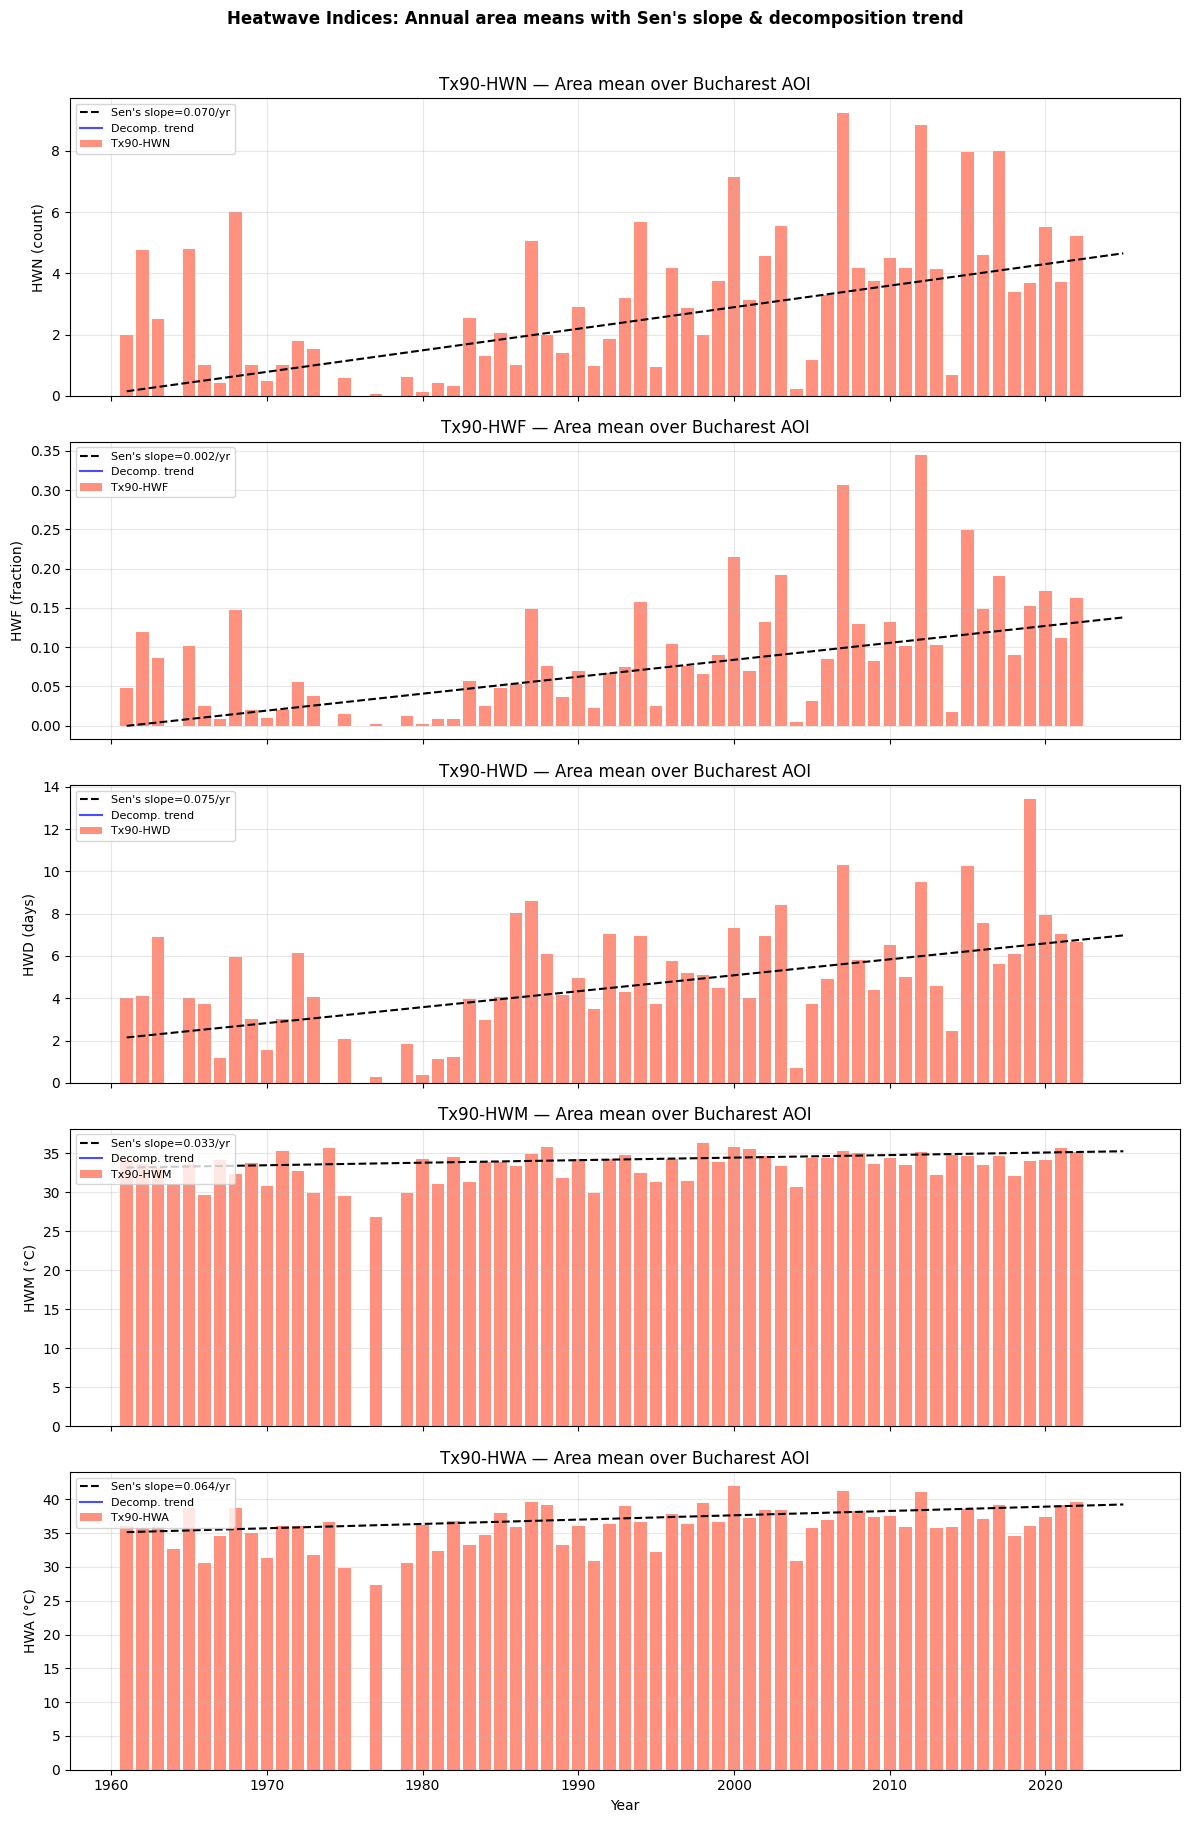

✅ Time-series diagnostic plot saved.


In [ ]:
from scipy import stats as sp_stats

# Compute area-averaged time series for each index (spatial mean over AOI)
area_ts = {}
for idx_name, da in indices.items():
    area_ts[idx_name] = np.nanmean(da.values, axis=(1,2))  # (nyear,)

fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)

for ax, (idx_name, ts) in zip(axes, area_ts.items()):
    da   = indices[idx_name]
    units = da.attrs.get('units','')

    # Sen's slope line
    slope = float(np.nanmean(mk_stats_all[idx_name]['slope']))
    intcp = float(np.nanmean(mk_stats_all[idx_name]['intercept']))
    trend_line = slope * np.arange(len(years)) + intcp

    ax.bar(years, ts, color='tomato', alpha=0.7, label=f'Tx90-{idx_name}')
    ax.plot(years, trend_line, 'k--', lw=1.5, label=f"Sen's slope={slope:.3f}/yr")

    # Decomposition trend component
    trend_comp = np.nanmean(decomp_all[idx_name]['trend_comp'], axis=(1,2))
    ax.plot(years, trend_comp, 'b-', lw=1.5, alpha=0.7, label='Decomp. trend')

    ax.set_ylabel(f'{idx_name} ({units})')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_title(f'Tx90-{idx_name} — Area mean over Bucharest AOI')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Year')
plt.suptitle('Heatwave Indices: Annual area means with Sen\'s slope & decomposition trend',
             y=1.01, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MAPS_DIR, 'HW_indices_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Time-series diagnostic plot saved.')

## 🧩 BLOCK 16 — Seasonal decomposition component maps (spatial)

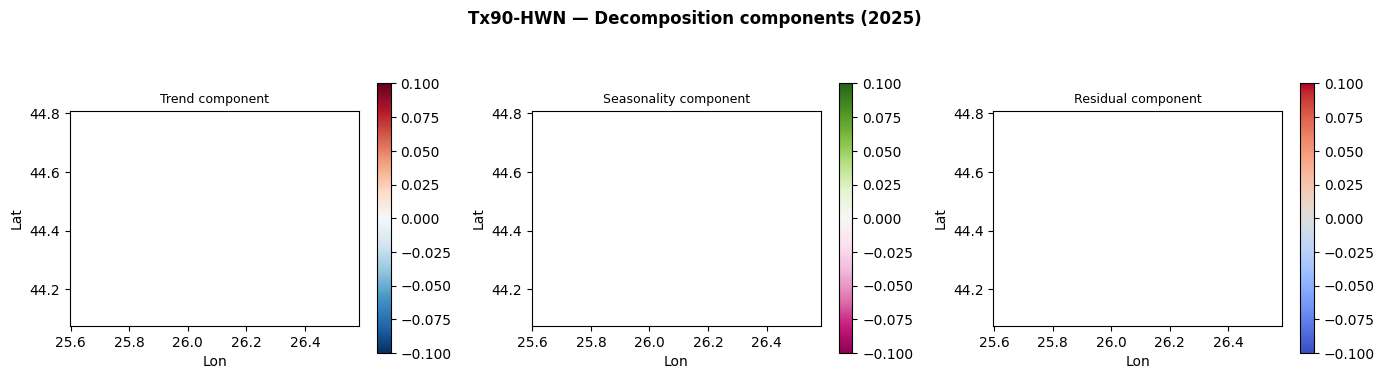

✅ HWN decomposition map saved.


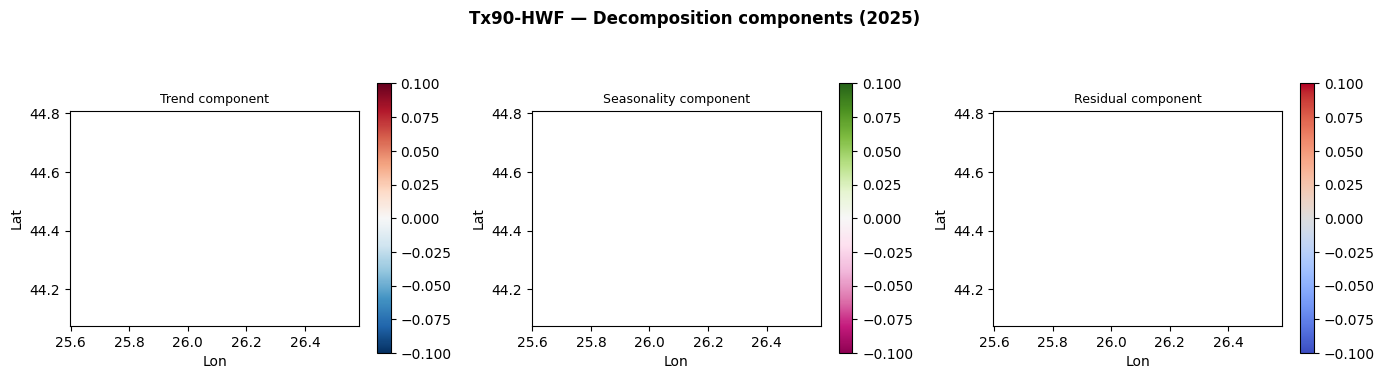

✅ HWF decomposition map saved.


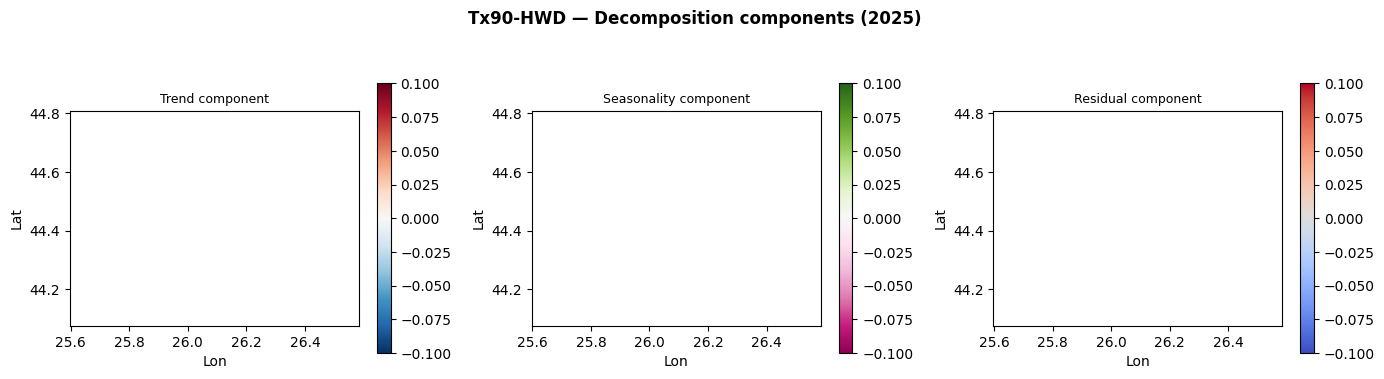

✅ HWD decomposition map saved.


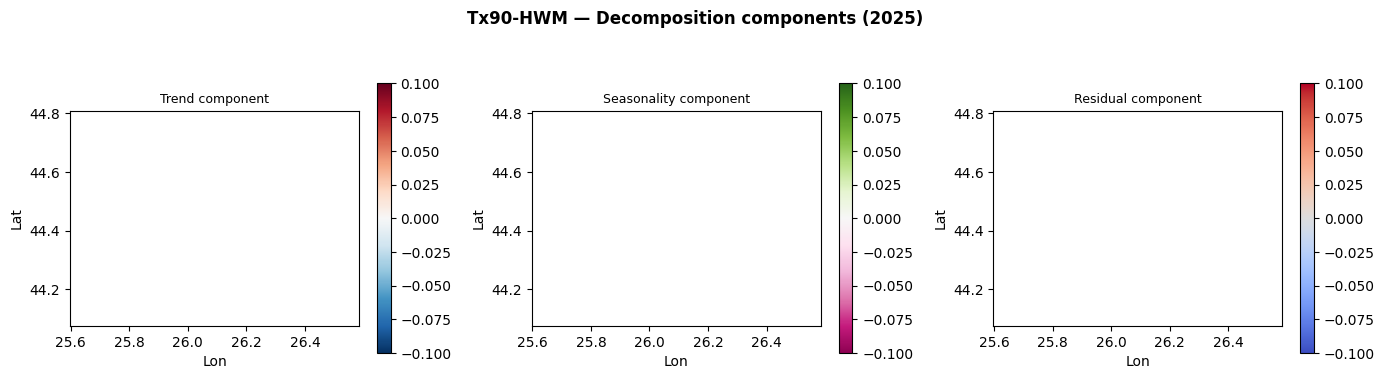

✅ HWM decomposition map saved.


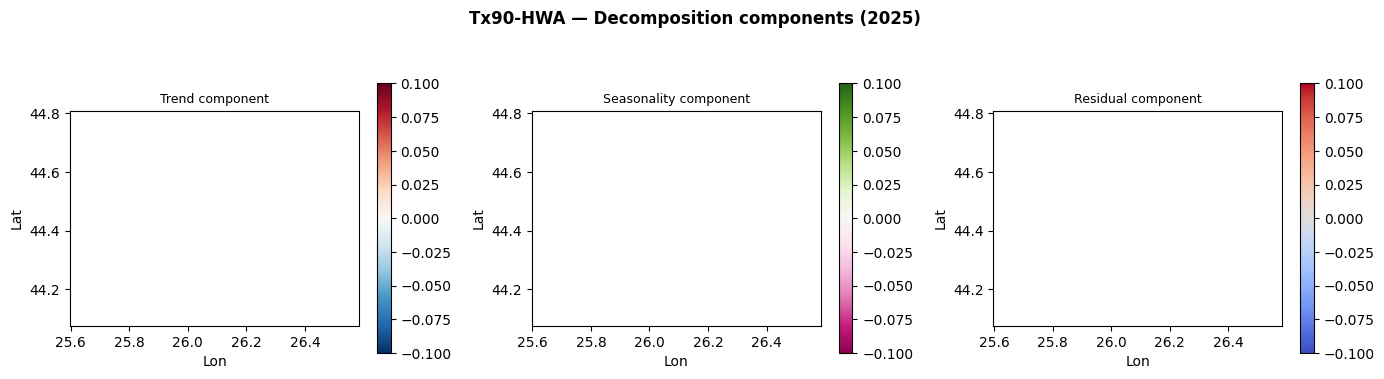

✅ HWA decomposition map saved.


In [ ]:
DECOMP_YEAR_IDX = -1   # last year in the time axis

for idx_name in indices:
    fig, axs = plt.subplots(1, 3, figsize=(14, 4))
    comp_labels = {
        'trend_comp'   : ('Trend component', 'RdBu_r'),
        'seasonal_comp': ('Seasonality component', 'PiYG'),
        'resid_comp'   : ('Residual component', 'coolwarm')
    }
    for ax, (cname, (clabel, cmap)) in zip(axs, comp_labels.items()):
        data = decomp_all[idx_name][cname][DECOMP_YEAR_IDX]  # (nlat,nlon)
        vabs = np.nanpercentile(np.abs(data), 95)
        im = ax.imshow(data, origin='lower',
                       extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                       cmap=cmap, vmin=-vabs, vmax=vabs)
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(clabel, fontsize=9)
        ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
    fig.suptitle(f'Tx90-{idx_name} — Decomposition components ({int(years[DECOMP_YEAR_IDX])})',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MAPS_DIR, f'Decomp_{idx_name}_spatial.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ {idx_name} decomposition map saved.')

## 📊 BLOCK 17 — MK trend significance maps (spatial, per index)

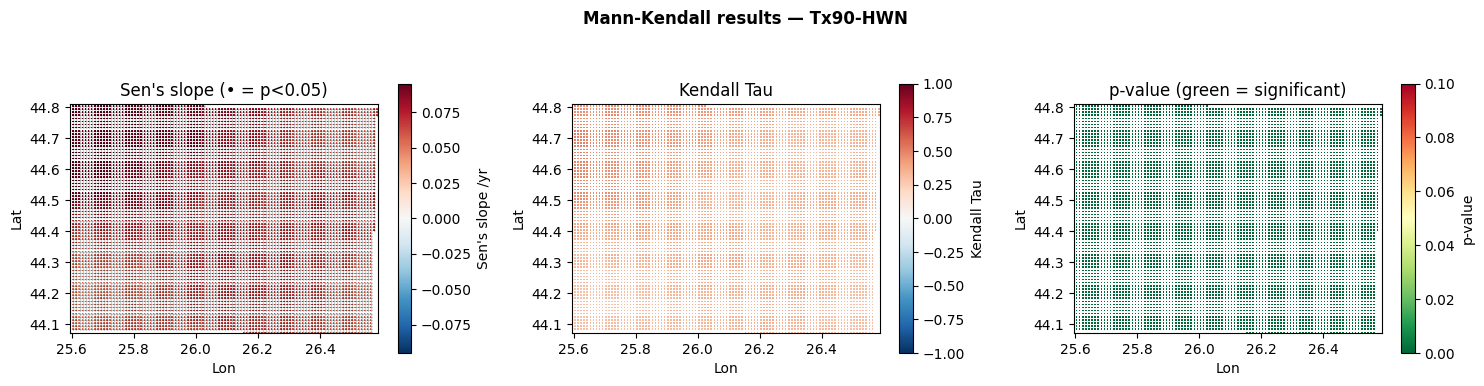

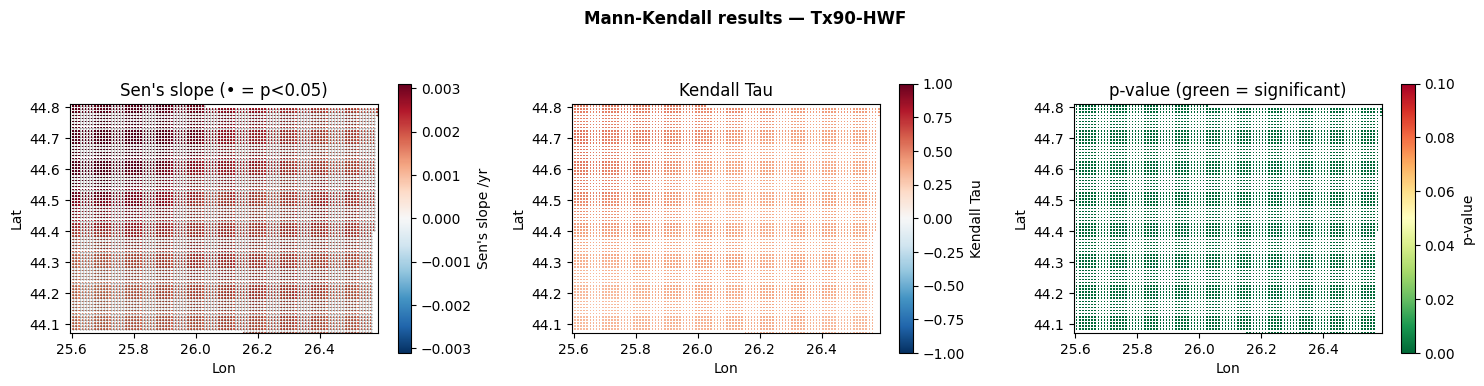

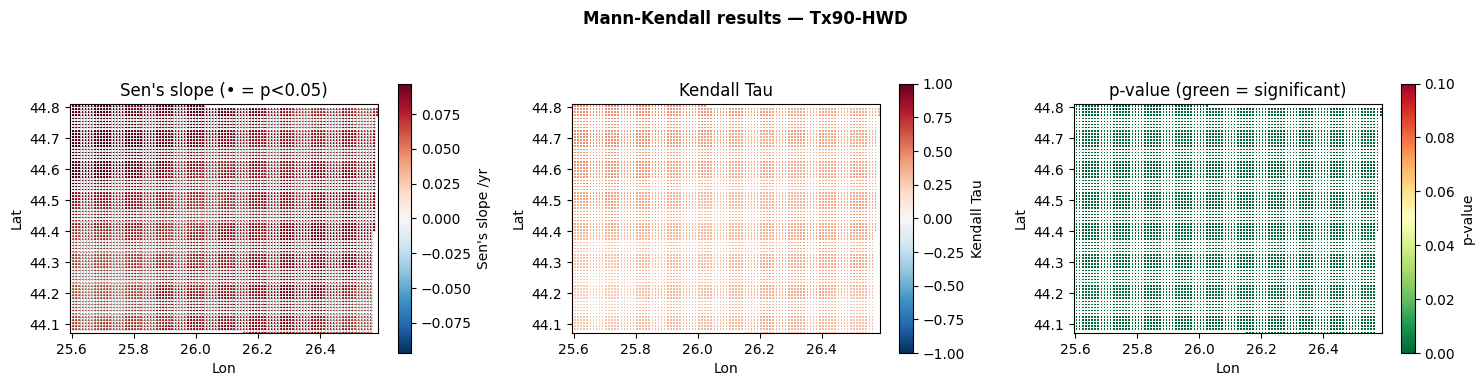

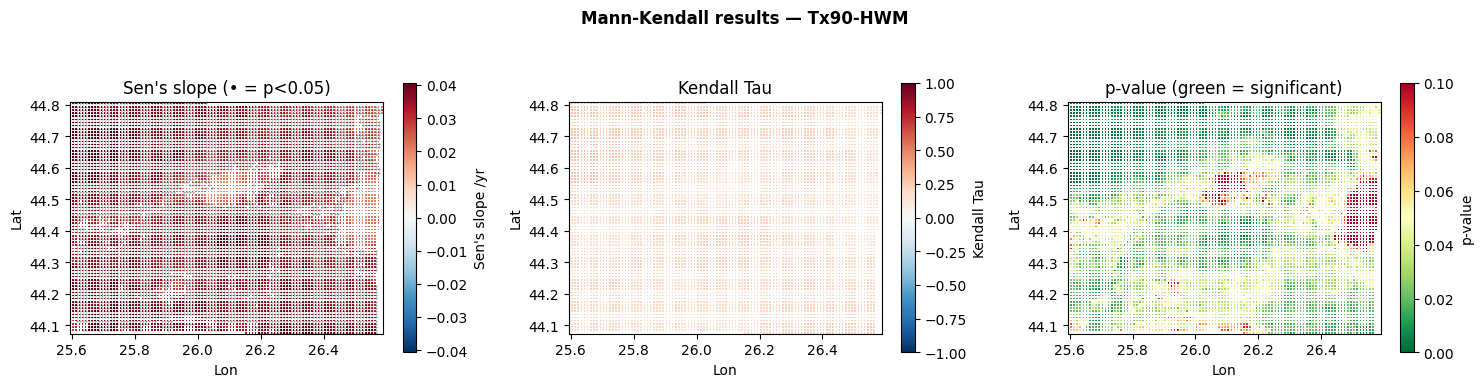

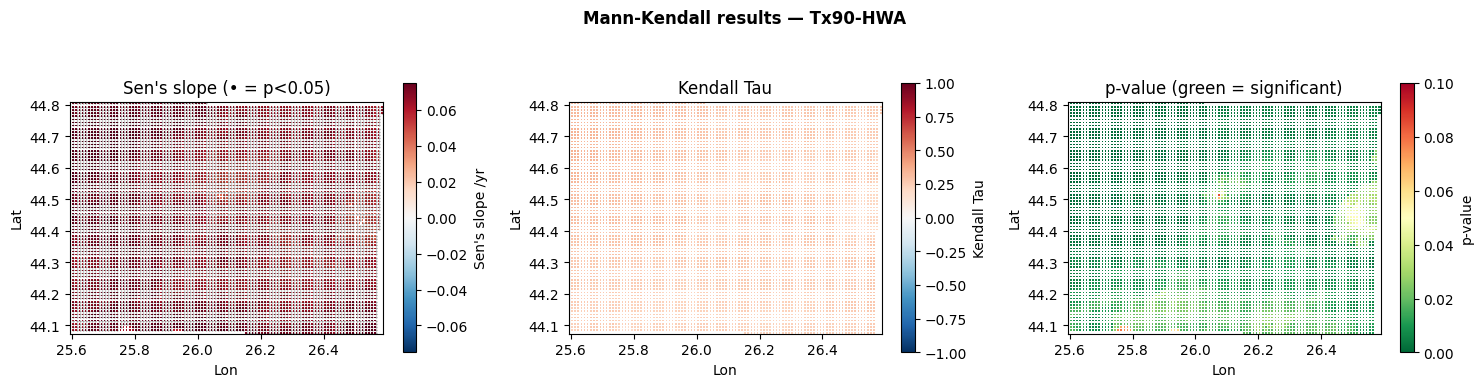

In [ ]:
for idx_name in indices:
    slope_map = mk_stats_all[idx_name]['slope']
    tau_map   = mk_stats_all[idx_name]['Tau']
    sig_map   = mk_stats_all[idx_name]['significant']
    p_map     = mk_stats_all[idx_name]['p']

    lon_g, lat_g = np.meshgrid(lons, lats)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    # Sen's slope
    vabs = np.nanpercentile(np.abs(slope_map), 95)
    im0 = axs[0].pcolormesh(lon_g, lat_g, slope_map,
                             cmap='RdBu_r', vmin=-vabs, vmax=vabs, shading='auto')
    plt.colorbar(im0, ax=axs[0], shrink=0.8, label="Sen's slope /yr")
    axs[0].scatter(lon_g[sig_map == 1], lat_g[sig_map == 1],
                   s=1, c='k', marker='.', alpha=0.4)
    axs[0].set_title("Sen's slope (• = p<0.05)")

    # Kendall Tau
    im1 = axs[1].pcolormesh(lon_g, lat_g, tau_map,
                             cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
    plt.colorbar(im1, ax=axs[1], shrink=0.8, label='Kendall Tau')
    axs[1].set_title('Kendall Tau')

    # p-value
    im2 = axs[2].pcolormesh(lon_g, lat_g, p_map,
                             cmap='RdYlGn_r', vmin=0, vmax=0.1, shading='auto')
    plt.colorbar(im2, ax=axs[2], shrink=0.8, label='p-value')
    axs[2].set_title('p-value (green = significant)')

    for ax in axs:
        ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
        ax.set_aspect('equal')

    fig.suptitle(f'Mann-Kendall results — Tx90-{idx_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MAPS_DIR, f'MK_{idx_name}_spatial.png'), dpi=150, bbox_inches='tight')
    plt.show()

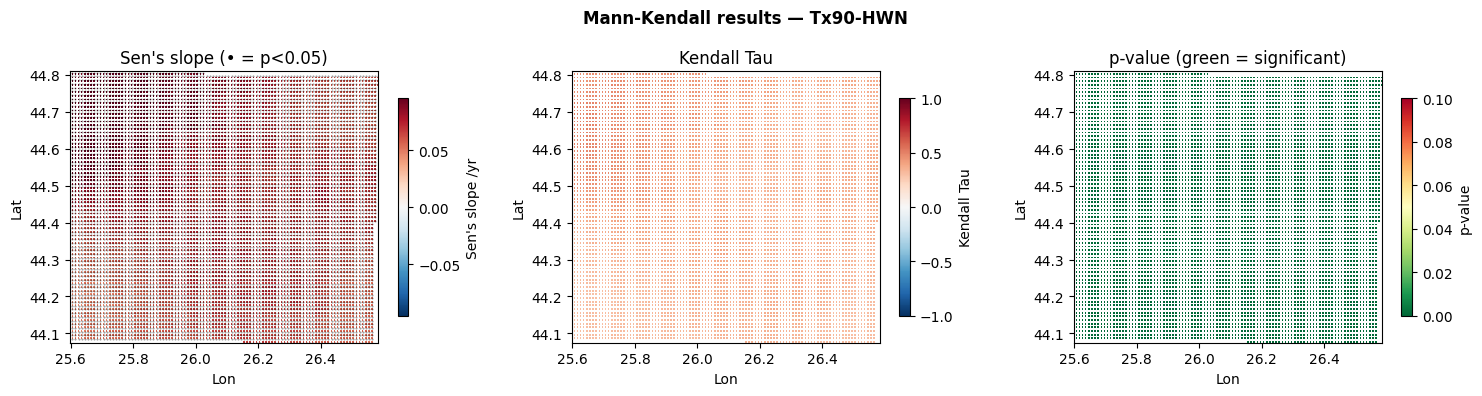

✅ HWN: GeoTIFFs + map saved.


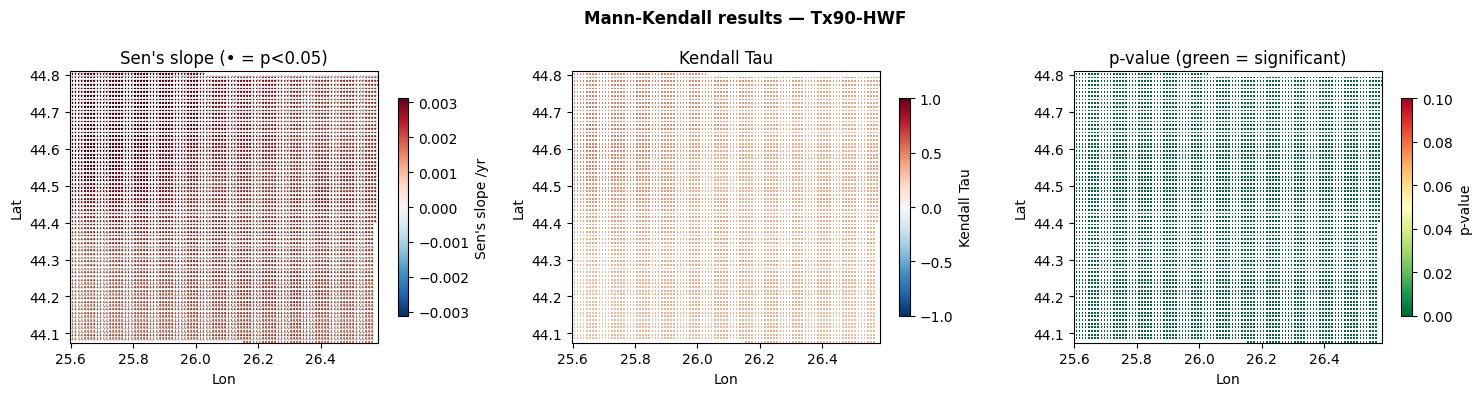

✅ HWF: GeoTIFFs + map saved.


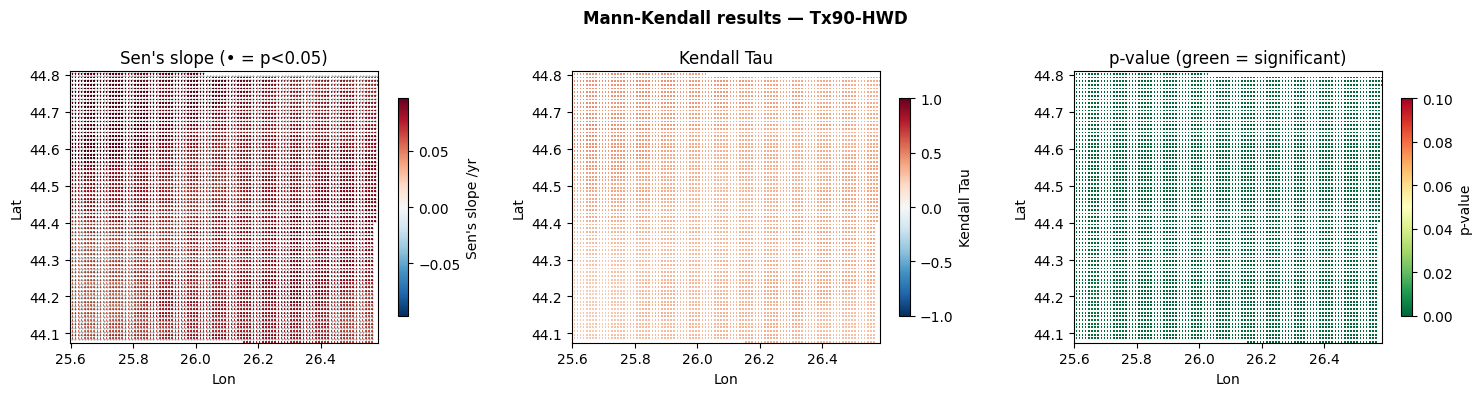

✅ HWD: GeoTIFFs + map saved.


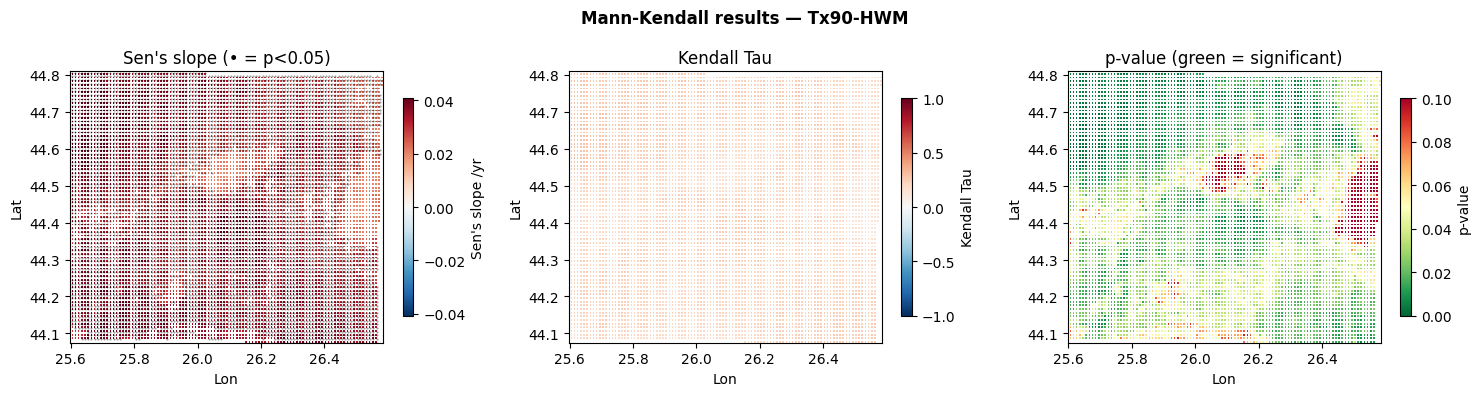

✅ HWM: GeoTIFFs + map saved.


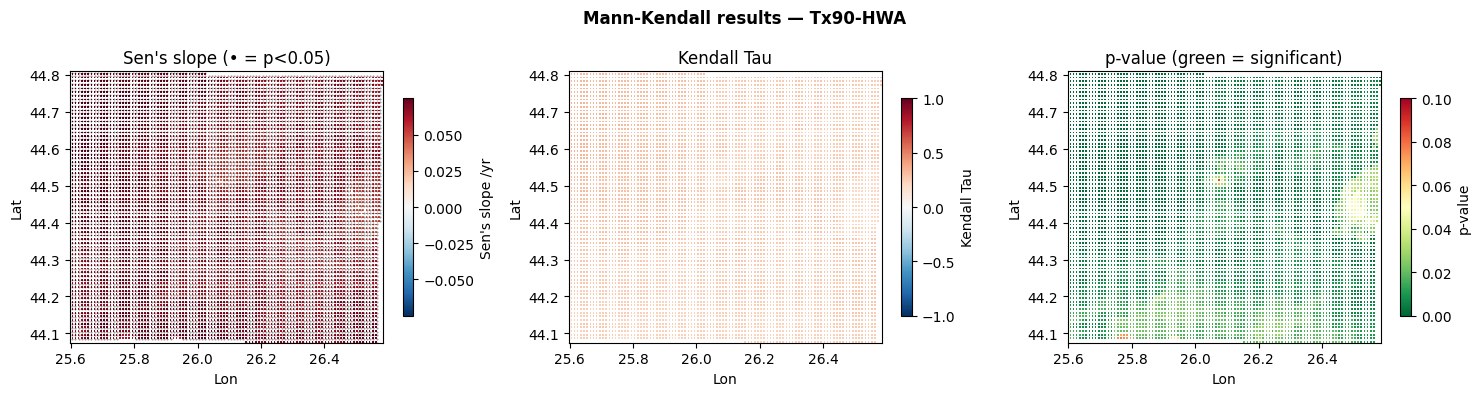

✅ HWA: GeoTIFFs + map saved.


In [ ]:
import rasterio
from rasterio.transform import from_bounds
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

def save_geotiff(data, lats, lons, filepath):
    """Save a 2D numpy array as a GeoTIFF."""
    transform = from_bounds(lons.min(), lats.min(), lons.max(), lats.max(),
                            data.shape[1], data.shape[0])
    with rasterio.open(
        filepath, 'w', driver='GTiff',
        height=data.shape[0], width=data.shape[1],
        count=1, dtype=data.dtype,
        crs='EPSG:4326', transform=transform,
        nodata=np.nan
    ) as dst:
        dst.write(np.flipud(data), 1)   # flipud: rasterio origin is top-left

for idx_name in indices:
    slope_map = mk_stats_all[idx_name]['slope']
    tau_map   = mk_stats_all[idx_name]['Tau']
    sig_map   = mk_stats_all[idx_name]['significant']
    p_map     = mk_stats_all[idx_name]['p']

    # Save GeoTIFFs
    save_geotiff(slope_map, lats, lons,
                 os.path.join(STATS_DIR, f'MK_{idx_name}_slope.tif'))
    save_geotiff(tau_map,   lats, lons,
                 os.path.join(STATS_DIR, f'MK_{idx_name}_tau.tif'))
    save_geotiff(p_map,     lats, lons,
                 os.path.join(STATS_DIR, f'MK_{idx_name}_pvalue.tif'))

    # Plot using imshow with interpolation='nearest' — no gaps
    lon_g, lat_g = np.meshgrid(lons, lats)
    extent = [lons.min(), lons.max(), lats.min(), lats.max()]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    vabs = np.nanpercentile(np.abs(slope_map), 95)

    im0 = axs[0].imshow(slope_map, origin='lower', extent=extent,
                        cmap='RdBu_r', vmin=-vabs, vmax=vabs,
                        interpolation='nearest', aspect='auto')
    plt.colorbar(im0, ax=axs[0], shrink=0.8, label="Sen's slope /yr")
    # Stipple significant pixels
    axs[0].scatter(lon_g[sig_map == 1], lat_g[sig_map == 1],
                   s=1, c='k', marker='.', alpha=0.4)
    axs[0].set_title("Sen's slope (• = p<0.05)")

    im1 = axs[1].imshow(tau_map, origin='lower', extent=extent,
                        cmap='RdBu_r', vmin=-1, vmax=1,
                        interpolation='nearest', aspect='auto')
    plt.colorbar(im1, ax=axs[1], shrink=0.8, label='Kendall Tau')
    axs[1].set_title('Kendall Tau')

    im2 = axs[2].imshow(p_map, origin='lower', extent=extent,
                        cmap='RdYlGn_r', vmin=0, vmax=0.1,
                        interpolation='nearest', aspect='auto')
    plt.colorbar(im2, ax=axs[2], shrink=0.8, label='p-value')
    axs[2].set_title('p-value (green = significant)')

    for ax in axs:
        ax.set_xlabel('Lon'); ax.set_ylabel('Lat')

    fig.suptitle(f'Mann-Kendall results — Tx90-{idx_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MAPS_DIR, f'MK_{idx_name}_spatial.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ {idx_name}: GeoTIFFs + map saved.')

## 💡 BLOCK 18 — Suggested additional analyses
The following cell does not run code — it documents additional analyses you can add to this project.

### 🔬 Suggested additional analyses for this dataset

**Temperature extremes beyond heatwaves:**
- **TXx (annual maximum TX)** — hottest day of each year, trend maps
- **TX90p (warm day frequency)** — fraction of days above 90th pctile, entire year not just season
- **WSDI (Warm Spell Duration Index)** — extended warm periods for all months

**Heatwave characteristics deeper dive:**
- **Compound heatwave events** — clustering of multiple events in one summer
- **Inter-arrival time** — years between major events (return period)
- **Heatwave intensity anomaly** — how much TX exceeds the 90th pctile during events
- **Urban Heat Island signal** — compare pixels within city centre vs. rural AOI pixels

**Statistical / attribution:**
- **Change-point detection** (Pettitt test, CUSUM) — find year when trends shift significantly
- **Extreme Value Analysis** (GEV / Gumbel) — return periods for TXx events
- **Correlation with large-scale drivers** — compare HWN/HWA against SST indices (AMO, NAO, Blocking index)
- **Multi-variate trend analysis** — PCA/EOF on the 5 indices simultaneously across pixels

**Visualisation:**
- **Hovmöller diagrams** — latitude-time or longitude-time plots of daily HW mask
- **Heatwave frequency heatmap calendar** — daily calendar plot (like GitHub contribution chart)
- **Violin / box plots** — distribution of HW index values by decade (1960s, 70s … 2020s)
- **Interactive Plotly dashboard** — multi-panel with sliders for year/index selection
- **Animated GIF/MP4 of annual HWN maps** — each frame = one year, export for presentations

**Climate projections linkage:**
- If you have CMIP6 or CORDEX data, compare observed trends vs. modelled projections
- **Delta method bias correction** — correct model output with ANM-derived thresholds

**Health / impact linkage:**
- Overlay hospital admission or mortality data on HWF/HWA maps
- Compute **Humidex or Heat Index** (requires relative humidity) for risk mapping

## ✅ BLOCK 19 — Final summary & output file inventory

In [ ]:
import os

print('=' * 60)
print('  HEATWAVE ANALYSIS – BUCHAREST – OUTPUT SUMMARY')
print('=' * 60)

for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}📁 {os.path.basename(root)}/')
    for f in sorted(files):
        size_mb = os.path.getsize(os.path.join(root,f)) / 1e6
        print(f'{indent}    📄 {f}  ({size_mb:.1f} MB)')

print('\n' + '=' * 60)
print('  ANALYSIS COMPLETE ✅')
print(f'  Years covered : 1961–2025')
print(f'  Baseline      : {BASELINE_START}–{BASELINE_END}')
print(f'  HW definition : ≥{HW_MIN_DAYS} days with TX > Tx{HW_PERCENTILE}p')
print(f'  Indices       : HWN, HWF, HWD, HWM, HWA')
print(f'  Formats saved : NetCDF (.nc) + Zarr (.zarr)')
print('=' * 60)

  HEATWAVE ANALYSIS – BUCHAREST – OUTPUT SUMMARY
📁 00_Proiectul_meu/
    📄 Bucharest_Heatwave_Analysis.ipynb  (2.1 MB)
  📁 00_Baza_date/
    📁 01_AOI/
        📄 00_AOI.rar  (0.0 MB)
  📁 01_Date_prelucrate/
      📄 TX_Bucharest_1961_2025_merged.nc  (174.2 MB)
  📁 02_Zarr_files/
    📁 TX_Bucharest_1961_2025_merged.zarr/
        📄 zarr.json  (0.0 MB)
      📁 daily_maximum_temp/
          📄 zarr.json  (0.0 MB)
        📁 c/
          📁 8/
            📁 0/
                📄 0  (0.1 MB)
                📄 1  (0.1 MB)
                📄 2  (0.1 MB)
                📄 3  (0.1 MB)
            📁 2/
                📄 0  (0.1 MB)
                📄 1  (0.1 MB)
                📄 2  (0.1 MB)
                📄 3  (0.1 MB)
            📁 1/
                📄 0  (0.1 MB)
                📄 1  (0.1 MB)
                📄 2  (0.1 MB)
                📄 3  (0.1 MB)
          📁 60/
            📁 0/
                📄 0  (0.1 MB)
                📄 1  (0.1 MB)
                📄 2  (0.1 MB)
                📄 3  (0.1 MB

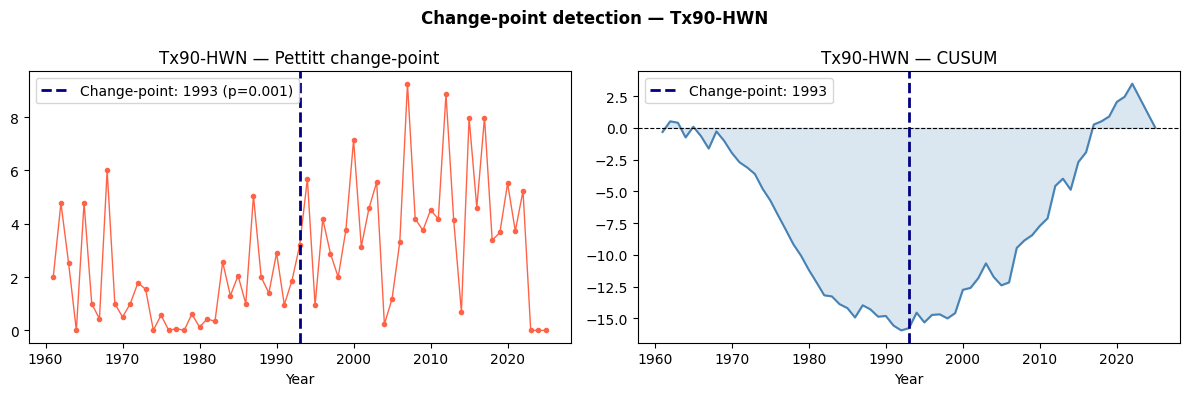

  HWN: change-point detected at 1993 (p=0.0009)


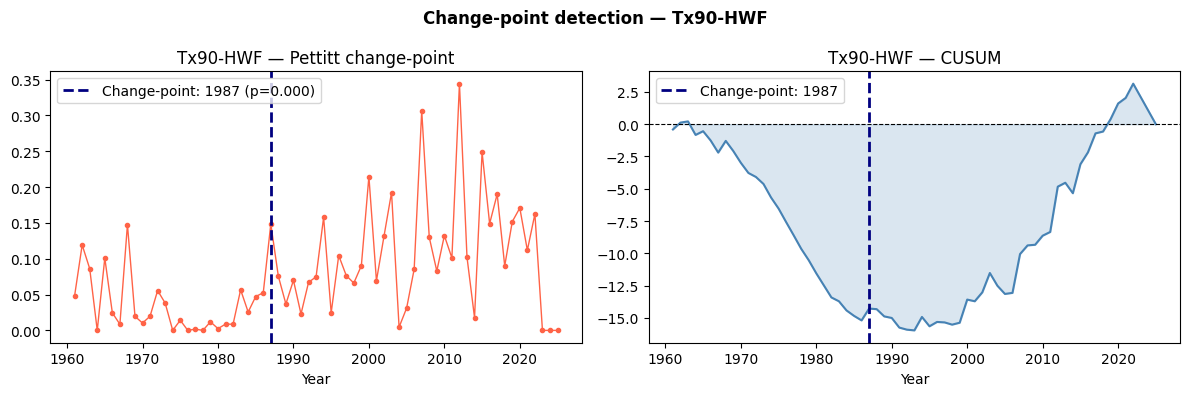

  HWF: change-point detected at 1987 (p=0.0004)


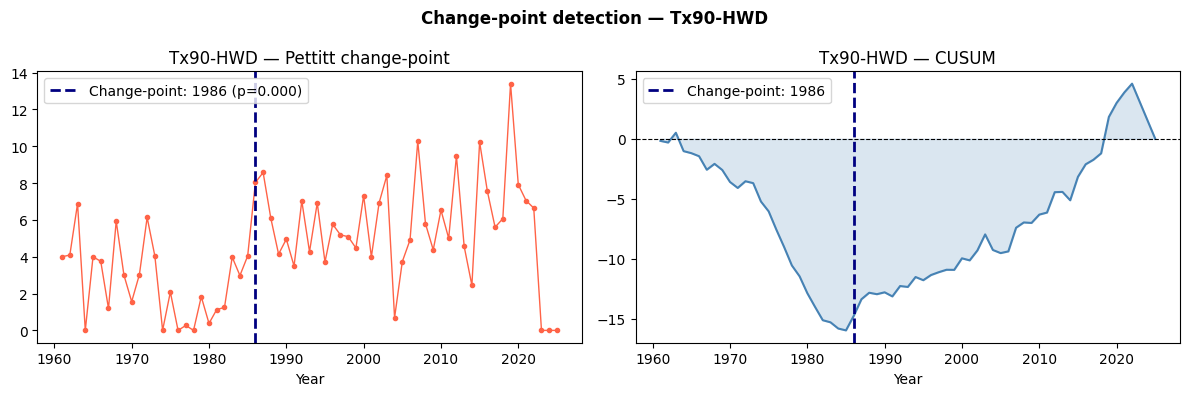

  HWD: change-point detected at 1986 (p=0.0001)


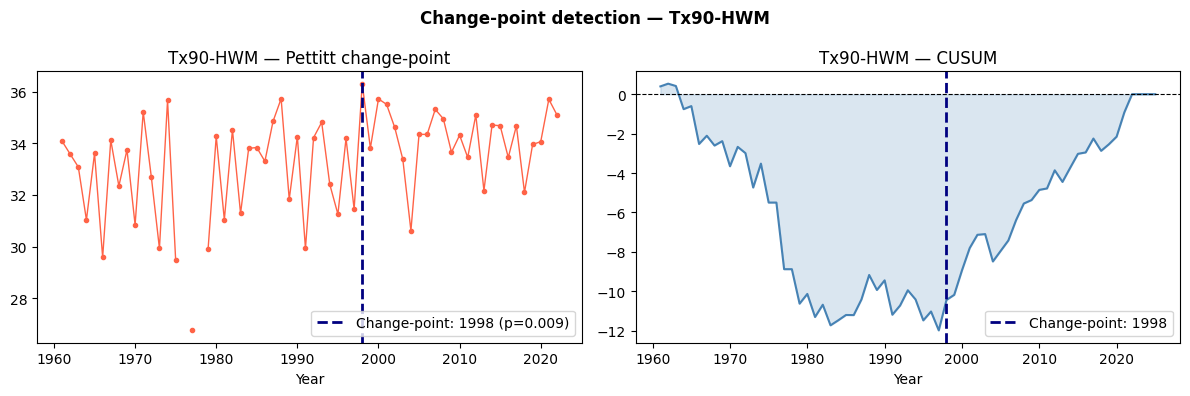

  HWM: change-point detected at 1998 (p=0.0086)


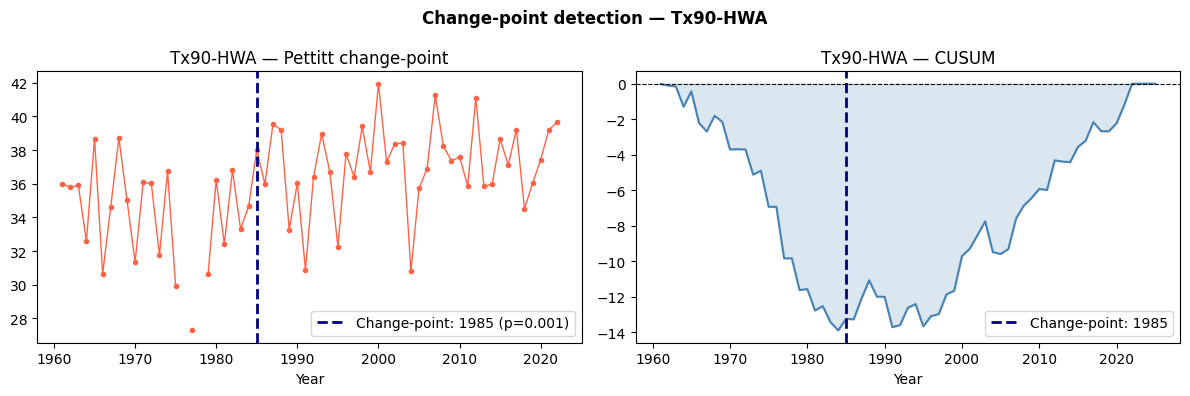

  HWA: change-point detected at 1985 (p=0.0012)
✅ Change-point detection complete.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK A — Change-point detection: Pettitt test + CUSUM per index
# ══════════════════════════════════════════════════════════════════════════════
!pip install -q pyhomogeneity

import pyhomogeneity as hg
import matplotlib.pyplot as plt
import numpy as np

changepoint_results = {}

for idx_name, da in indices.items():
    arr = da.values  # (nyear, nlat, nlon)
    ts  = np.nanmean(arr, axis=(1,2))  # area mean

    # Pettitt test
    pett  = hg.pettitt_test(ts)
    cp_yr = int(years[pett.cp])

    # CUSUM
    ts_norm = (ts - np.nanmean(ts)) / np.nanstd(ts)
    cusum   = np.nancumsum(ts_norm)

    changepoint_results[idx_name] = {'pettitt_year': cp_yr, 'pettitt_p': pett.p,
                                      'cusum': cusum}

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Pettitt
    axs[0].plot(years, ts, 'o-', color='tomato', ms=3, lw=1)
    axs[0].axvline(cp_yr, color='navy', lw=2, ls='--',
                   label=f'Change-point: {cp_yr} (p={pett.p:.3f})')
    axs[0].set_title(f'Tx90-{idx_name} — Pettitt change-point')
    axs[0].set_xlabel('Year'); axs[0].legend()

    # CUSUM
    axs[1].plot(years, cusum, color='steelblue', lw=1.5)
    axs[1].axhline(0, color='k', lw=0.8, ls='--')
    axs[1].axvline(cp_yr, color='navy', lw=2, ls='--', label=f'Change-point: {cp_yr}')
    axs[1].fill_between(years, cusum, 0, alpha=0.2, color='steelblue')
    axs[1].set_title(f'Tx90-{idx_name} — CUSUM')
    axs[1].set_xlabel('Year'); axs[1].legend()

    plt.suptitle(f'Change-point detection — Tx90-{idx_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MAPS_DIR, f'Changepoint_{idx_name}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  {idx_name}: change-point detected at {cp_yr} (p={pett.p:.4f})')

print('✅ Change-point detection complete.')

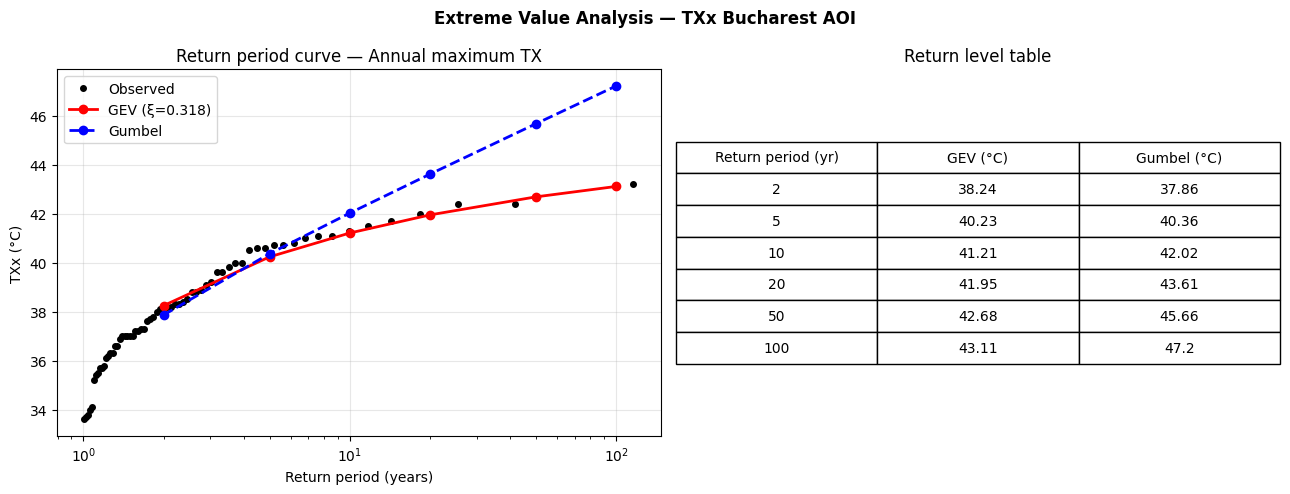

✅ GEV/Gumbel analysis complete.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK B — Extreme Value Analysis: GEV / Gumbel fit + return periods for TXx
# ══════════════════════════════════════════════════════════════════════════════
from scipy.stats import genextreme, gumbel_r
import matplotlib.pyplot as plt

# Annual maximum TX (TXx) — area mean
TXx_series = np.nanmax(TX_vals, axis=0)   # (nlat,nlon) — max over all time
# For return period analysis use area-averaged annual max
TXx_annual = np.array([np.nanmax(TX_vals[TX_year == y]) for y in years])

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

return_periods = np.array([2, 5, 10, 20, 50, 100])

# ── GEV fit ──────────────────────────────────────────────────────────────────
gev_params = genextreme.fit(TXx_annual)   # (c, loc, scale)
gev_c, gev_loc, gev_scale = gev_params
gev_return_levels = genextreme.ppf(1 - 1/return_periods, *gev_params)

# ── Gumbel fit ───────────────────────────────────────────────────────────────
gum_params = gumbel_r.fit(TXx_annual)
gum_return_levels = gumbel_r.ppf(1 - 1/return_periods, *gum_params)

# Empirical plotting positions (Gringorten formula)
n   = len(TXx_annual)
sorted_tx = np.sort(TXx_annual)
emp_rp    = 1 / (1 - (np.arange(1, n+1) - 0.44) / (n + 0.12))

axs[0].semilogx(emp_rp, sorted_tx, 'ko', ms=4, label='Observed')
axs[0].semilogx(return_periods, gev_return_levels, 'r-o', lw=2, label=f'GEV (ξ={gev_c:.3f})')
axs[0].semilogx(return_periods, gum_return_levels, 'b--o', lw=2, label='Gumbel')
axs[0].set_xlabel('Return period (years)')
axs[0].set_ylabel('TXx (°C)')
axs[0].set_title('Return period curve — Annual maximum TX')
axs[0].legend(); axs[0].grid(alpha=0.3)

# Return levels table
rp_df = {'Return period': return_periods,
         'GEV (°C)': gev_return_levels.round(2),
         'Gumbel (°C)': gum_return_levels.round(2)}
axs[1].axis('off')
tbl = axs[1].table(
    cellText=list(zip(return_periods, gev_return_levels.round(2), gum_return_levels.round(2))),
    colLabels=['Return period (yr)', 'GEV (°C)', 'Gumbel (°C)'],
    loc='center', cellLoc='center'
)
tbl.scale(1, 2)
axs[1].set_title('Return level table')

plt.suptitle('Extreme Value Analysis — TXx Bucharest AOI', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MAPS_DIR, 'EVA_TXx_return_periods.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ GEV/Gumbel analysis complete.')

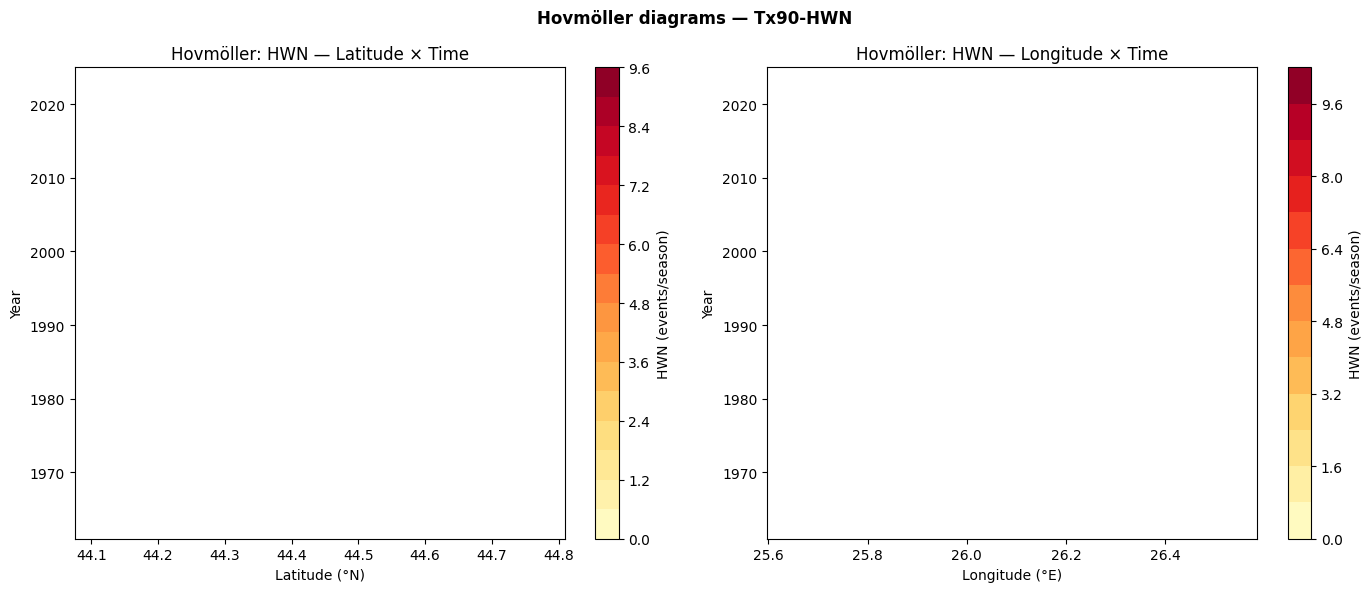

✅ Hovmöller diagrams saved.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK C — Hovmöller diagrams (latitude-time and longitude-time)
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use annual HWN for Hovmöller (or switch to HW_daily for daily resolution)
HWN_arr = indices['HWN'].values   # (nyear, nlat, nlon)

# Latitude-time: average over longitudes
hov_lat = np.nanmean(HWN_arr, axis=2)   # (nyear, nlat)
# Longitude-time: average over latitudes
hov_lon = np.nanmean(HWN_arr, axis=1)   # (nyear, nlon)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Latitude-time
im0 = axs[0].contourf(lats, years, hov_lat, levels=15, cmap='YlOrRd')
plt.colorbar(im0, ax=axs[0], label='HWN (events/season)')
axs[0].set_xlabel('Latitude (°N)')
axs[0].set_ylabel('Year')
axs[0].set_title('Hovmöller: HWN — Latitude × Time')

# Longitude-time
im1 = axs[1].contourf(lons, years, hov_lon, levels=15, cmap='YlOrRd')
plt.colorbar(im1, ax=axs[1], label='HWN (events/season)')
axs[1].set_xlabel('Longitude (°E)')
axs[1].set_ylabel('Year')
axs[1].set_title('Hovmöller: HWN — Longitude × Time')

plt.suptitle('Hovmöller diagrams — Tx90-HWN', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MAPS_DIR, 'Hovmoller_HWN.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Hovmöller diagrams saved.')

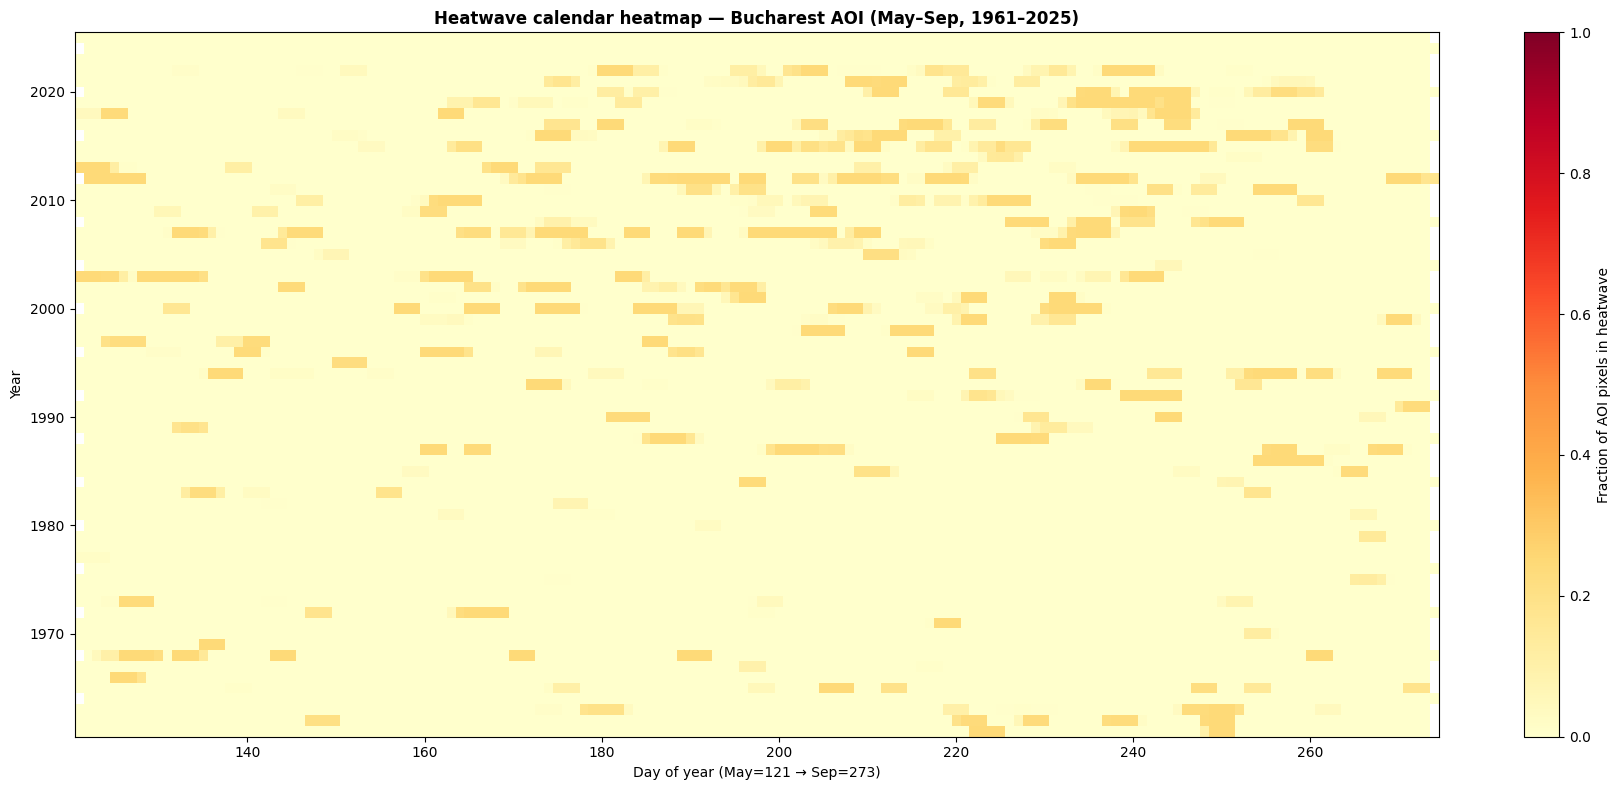

✅ Calendar heatmap saved.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK D — Heatwave calendar heatmap (GitHub-style) for area-mean HW daily mask
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Area-mean daily HW flag
hw_area = np.nanmean(HW_daily, axis=(1,2))   # (ntime,)  fraction of pixels in HW

df_hw = pd.DataFrame({'date': pd.to_datetime(TX_time), 'hw': hw_area})
df_hw['year']  = df_hw['date'].dt.year
df_hw['doy']   = df_hw['date'].dt.dayofyear

# Only heatwave season
df_season = df_hw[df_hw['date'].dt.month.isin(HEATWAVE_SEASON)]

pivot = df_season.pivot_table(index='year', columns='doy', values='hw', aggfunc='mean')

fig, ax = plt.subplots(figsize=(18, 8))
im = ax.pcolormesh(pivot.columns, pivot.index, pivot.values,
                   cmap='YlOrRd', vmin=0, vmax=1, shading='auto')
plt.colorbar(im, ax=ax, label='Fraction of AOI pixels in heatwave')
ax.set_xlabel('Day of year (May=121 → Sep=273)')
ax.set_ylabel('Year')
ax.set_title('Heatwave calendar heatmap — Bucharest AOI (May–Sep, 1961–2025)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MAPS_DIR, 'HW_calendar_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Calendar heatmap saved.')

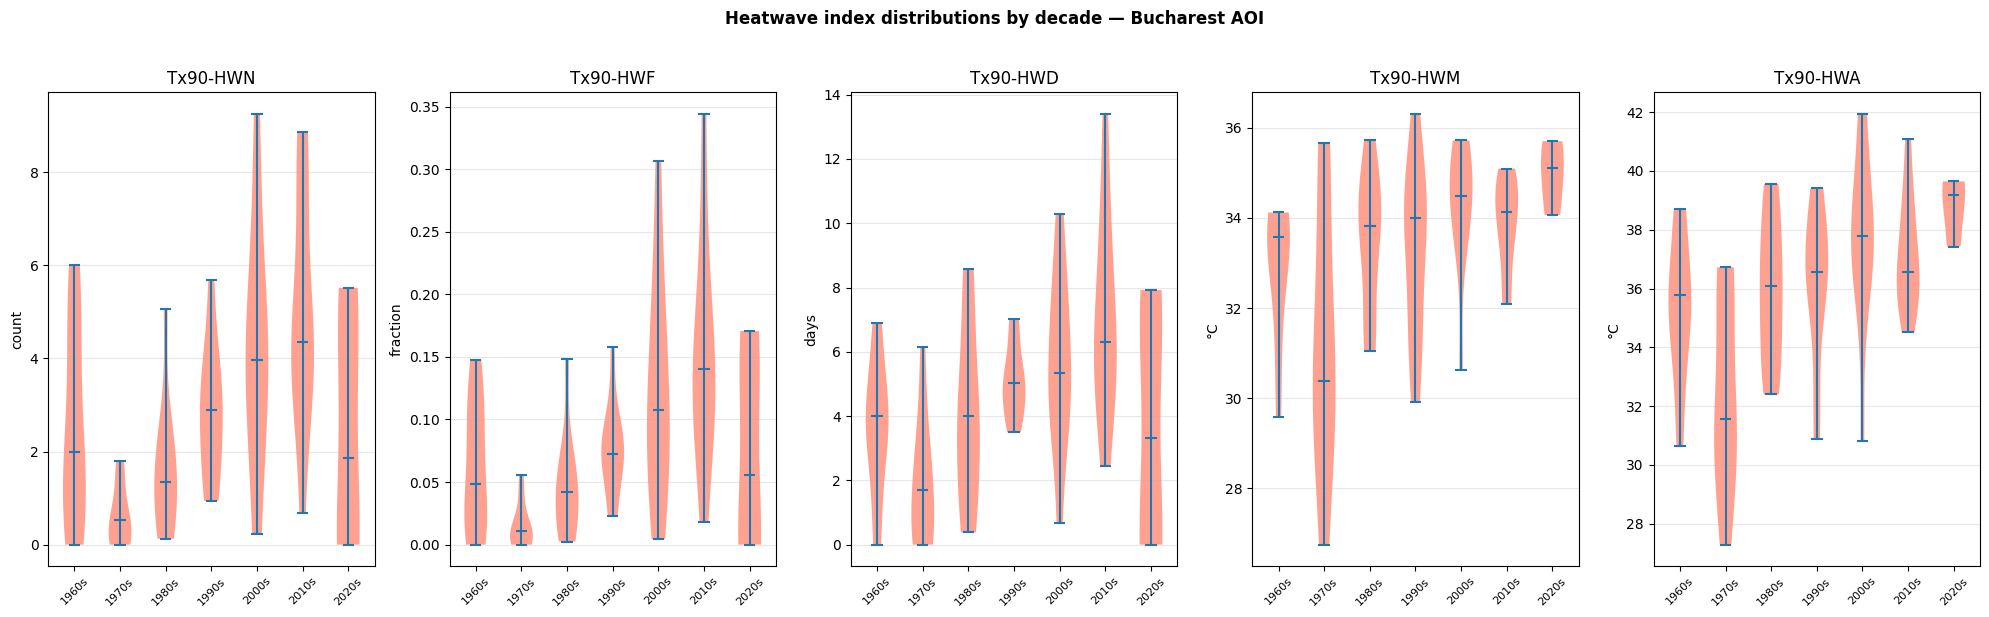

✅ Violin plots saved.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK E — Violin / box plots by decade for all 5 indices
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

decades      = [1960, 1970, 1980, 1990, 2000, 2010, 2020]
decade_labels = ['1960s','1970s','1980s','1990s','2000s','2010s','2020s']

fig, axs = plt.subplots(1, 5, figsize=(20, 6))

for ax, (idx_name, da) in zip(axs, indices.items()):
    arr     = da.values  # (nyear, nlat, nlon)
    ts_area = np.nanmean(arr, axis=(1,2))  # (nyear,)

    decade_data = []
    labels_used = []
    for d in decades:
        mask = (years >= d) & (years < d + 10)
        vals = ts_area[mask]
        vals = vals[~np.isnan(vals)]
        if len(vals) > 0:
            decade_data.append(vals)
            labels_used.append(f'{d}s')

    vp = ax.violinplot(decade_data, showmedians=True, showextrema=True)
    for body in vp['bodies']:
        body.set_facecolor('tomato'); body.set_alpha(0.6)

    ax.set_xticks(range(1, len(labels_used)+1))
    ax.set_xticklabels(labels_used, rotation=45, fontsize=8)
    ax.set_title(f'Tx90-{idx_name}')
    ax.set_ylabel(da.attrs.get('units',''))
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Heatwave index distributions by decade — Bucharest AOI',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(MAPS_DIR, 'HW_violin_by_decade.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Violin plots saved.')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK F — Interactive Plotly dashboard with year/index sliders
# ══════════════════════════════════════════════════════════════════════════════
!pip install -q plotly

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Area-mean time series for all indices
ts_dict = {name: np.nanmean(da.values, axis=(1,2)) for name, da in indices.items()}

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[f'Tx90-{n}' for n in ts_dict] + ['Sen\'s Slope Comparison'],
    specs=[[{'type':'scatter'}]*3, [{'type':'scatter'}]*3]
)

colors = {'HWN':'#e63946','HWF':'#f4a261','HWD':'#e9c46a','HWM':'#2a9d8f','HWA':'#264653'}
positions = {'HWN':(1,1),'HWF':(1,2),'HWD':(1,3),'HWM':(2,1),'HWA':(2,2)}

for idx_name, ts in ts_dict.items():
    r, c = positions[idx_name]
    slope = float(np.nanmean(mk_stats_all[idx_name]['slope']))
    intcp = float(np.nanmean(mk_stats_all[idx_name]['intercept']))
    trend = slope * np.arange(len(years)) + intcp

    fig.add_trace(go.Bar(x=list(years), y=ts.tolist(), name=idx_name,
                         marker_color=colors[idx_name], showlegend=False,
                         hovertemplate=f'<b>{idx_name}</b><br>Year: %{{x}}<br>Value: %{{y:.2f}}<extra></extra>'),
                  row=r, col=c)
    fig.add_trace(go.Scatter(x=list(years), y=trend.tolist(),
                             mode='lines', name=f'{idx_name} trend',
                             line=dict(color='black', width=1.5, dash='dash'),
                             showlegend=False,
                             hovertemplate=f'Trend<br>Year: %{{x}}<br>Value: %{{y:.2f}}<extra></extra>'),
                  row=r, col=c)

# Slopes comparison bar chart in (2,3)
slope_vals = [float(np.nanmean(mk_stats_all[n]['slope'])) for n in ts_dict]
fig.add_trace(go.Bar(x=list(ts_dict.keys()), y=slope_vals,
                     marker_color=[colors[n] for n in ts_dict],
                     name='Sen slope', showlegend=False,
                     hovertemplate='<b>%{x}</b><br>Slope: %{y:.4f}/yr<extra></extra>'),
              row=2, col=3)

fig.update_layout(
    height=700, width=1100,
    title_text='Heatwave Indices Dashboard — Bucharest AOI (1961–2025)',
    title_font_size=16,
    template='plotly_white',
    hovermode='x unified'
)

dashboard_path = os.path.join(MAPS_DIR, 'HW_dashboard_interactive.html')
fig.write_html(dashboard_path)
fig.show()
print(f'✅ Interactive dashboard saved: {dashboard_path}')

✅ Interactive dashboard saved: /content/drive/MyDrive/Workshop_DeltaHUB/00_Proiectul_meu/05_Maps/HW_dashboard_interactive.html


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK G — Animated GIF/MP4 of annual HWN maps (one frame per year)
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

HWN_arr = indices['HWN'].values   # (nyear, nlat, nlon)
vmin    = np.nanpercentile(HWN_arr, 2)
vmax    = np.nanpercentile(HWN_arr, 98)
extent  = [lons.min(), lons.max(), lats.min(), lats.max()]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(HWN_arr[0], origin='lower', extent=extent,
               cmap='YlOrRd', vmin=vmin, vmax=vmax,
               interpolation='nearest', aspect='auto')
cb = plt.colorbar(im, ax=ax, label='HWN (events/season)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
title = ax.set_title('')

def update(iy):
    im.set_data(HWN_arr[iy])
    title.set_text(f'Tx90-HWN — {int(years[iy])}')
    return [im, title]

ani = animation.FuncAnimation(fig, update, frames=len(years),
                               interval=300, blit=True)
plt.tight_layout()

# Save as GIF
gif_path = os.path.join(MAPS_DIR, 'HWN_annual_animation.gif')
ani.save(gif_path, writer='pillow', fps=4, dpi=100)
print(f'✅ GIF saved: {gif_path}')

# Also save as MP4 (requires ffmpeg)
try:
    mp4_path = os.path.join(MAPS_DIR, 'HWN_annual_animation.mp4')
    ani.save(mp4_path, writer='ffmpeg', fps=4, dpi=120)
    print(f'✅ MP4 saved: {mp4_path}')
except Exception as e:
    print(f'ℹ️  MP4 skipped (ffmpeg not available): {e}')

HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

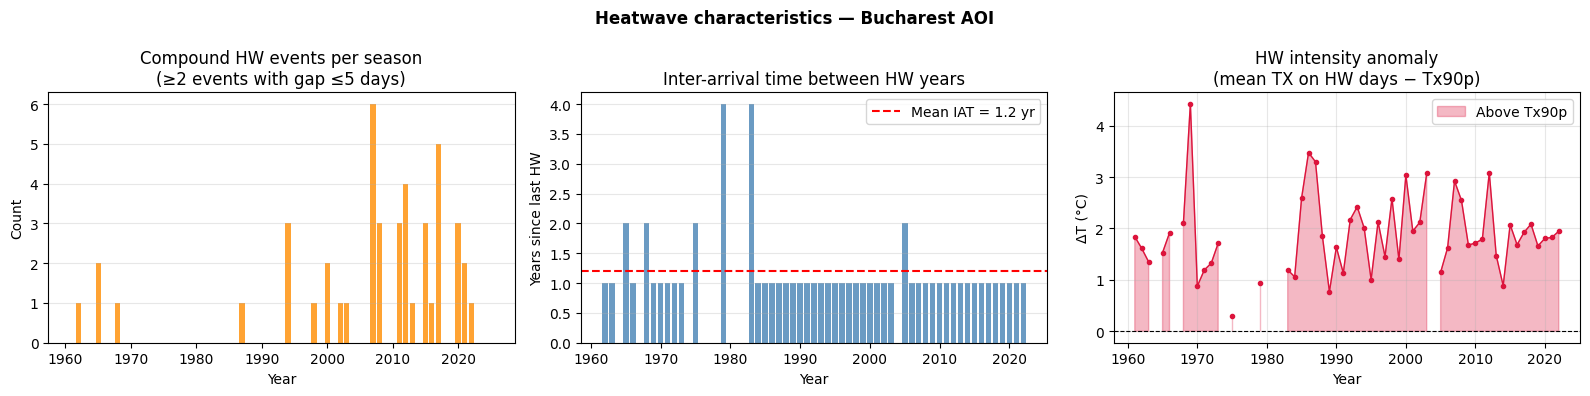

✅ Compound events, inter-arrival time, intensity anomaly complete.
 year  n_events  compound  intensity_anom
 2016         4         1        1.683975
 2017         9         5        1.924223
 2018         3         0        2.084372
 2019         4         0        1.660214
 2020         7         3        1.808139
 2021         5         2        1.824629
 2022         5         1        1.948071
 2023         0         0             NaN
 2024         0         0             NaN
 2025         0         0             NaN


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK H — Compound heatwave events, inter-arrival time, intensity anomaly
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt

# ── Area-mean time series from daily HW mask ──────────────────────────────────
hw_area = np.nanmean(HW_daily, axis=(1,2))   # fraction of pixels in HW each day
hw_bin  = (hw_area > 0.1).astype(int)        # >10% of AOI = "HW day"

df = pd.DataFrame({'date': pd.to_datetime(TX_time), 'hw': hw_bin,
                   'tx': np.nanmean(TX_vals, axis=(1,2))})
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month
df['doy']   = df['date'].dt.dayofyear

df_season = df[df['month'].isin(HEATWAVE_SEASON)].copy()

# ── Per-year compound event stats ────────────────────────────────────────────
records = []
for yr, grp in df_season.groupby('year'):
    hw_1d   = grp['hw'].values
    tx_1d   = grp['tx'].values
    doy_1d  = grp['doy'].values

    # Find individual HW events (runs ≥ 3)
    events = []
    i = 0
    while i < len(hw_1d):
        if hw_1d[i] == 1:
            j = i
            while j < len(hw_1d) and hw_1d[j] == 1:
                j += 1
            dur = j - i
            if dur >= HW_MIN_DAYS:
                events.append({'start_doy': doy_1d[i], 'duration': dur,
                                'mean_tx': np.mean(tx_1d[i:j])})
            i = j
        else:
            i += 1

    n_events = len(events)

    # Compound: ≥2 events with gap ≤5 days between them
    compound = 0
    if n_events >= 2:
        for k in range(len(events)-1):
            gap = events[k+1]['start_doy'] - (events[k]['start_doy'] + events[k]['duration'])
            if gap <= 5:
                compound += 1

    # Intensity anomaly: mean(TX on HW days) - tx90p on those days
    hw_mask_yr = (hw_1d == 1)
    if hw_mask_yr.sum() > 0:
        tx_hw  = tx_1d[hw_mask_yr]
        doy_hw = doy_1d[hw_mask_yr]
        tx90_hw = np.array([np.nanmean(tx90p[d-1]) for d in doy_hw])
        intensity_anom = float(np.mean(tx_hw - tx90_hw))
    else:
        intensity_anom = np.nan

    records.append({'year': yr, 'n_events': n_events,
                    'compound': compound, 'intensity_anom': intensity_anom})

df_rec = pd.DataFrame(records)

# Inter-arrival time: years with ≥1 HW event
hw_years = df_rec.loc[df_rec['n_events'] > 0, 'year'].values
iat = np.diff(hw_years)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

# Compound events per year
axs[0].bar(df_rec['year'], df_rec['compound'], color='darkorange', alpha=0.8)
axs[0].set_title('Compound HW events per season\n(≥2 events with gap ≤5 days)')
axs[0].set_xlabel('Year'); axs[0].set_ylabel('Count')
axs[0].grid(axis='y', alpha=0.3)

# Inter-arrival time
axs[1].bar(hw_years[1:], iat, color='steelblue', alpha=0.8)
axs[1].axhline(np.mean(iat), color='red', ls='--', lw=1.5,
               label=f'Mean IAT = {np.mean(iat):.1f} yr')
axs[1].set_title('Inter-arrival time between HW years')
axs[1].set_xlabel('Year'); axs[1].set_ylabel('Years since last HW')
axs[1].legend(); axs[1].grid(axis='y', alpha=0.3)

# Intensity anomaly
axs[2].plot(df_rec['year'], df_rec['intensity_anom'], 'o-',
            color='crimson', ms=3, lw=1)
axs[2].axhline(0, color='k', lw=0.8, ls='--')
axs[2].fill_between(df_rec['year'], df_rec['intensity_anom'], 0,
                     where=df_rec['intensity_anom'] > 0,
                     color='crimson', alpha=0.3, label='Above Tx90p')
axs[2].set_title('HW intensity anomaly\n(mean TX on HW days − Tx90p)')
axs[2].set_xlabel('Year'); axs[2].set_ylabel('ΔT (°C)')
axs[2].legend(); axs[2].grid(alpha=0.3)

plt.suptitle('Heatwave characteristics — Bucharest AOI', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MAPS_DIR, 'HW_compound_IAT_intensity.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save table
df_rec.to_csv(os.path.join(STATS_DIR, 'HW_compound_stats.csv'), index=False)
print('✅ Compound events, inter-arrival time, intensity anomaly complete.')
print(df_rec.tail(10).to_string(index=False))